Build Deep Sequential Models & Training it from Scratch
=======================================================

# Setup

In [1]:
import torch


if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [2]:
from copy import deepcopy
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import kagglehub
import datasets
import torch.nn as nn
import tokenizers
import transformers
import pandas as pd
import torchmetrics
from torchmetrics.classification import MultilabelAveragePrecision

torch.manual_seed(42)

In [3]:
import gc

def del_vars(variable_names=[]):
    for name in variable_names:
        try:
            del globals()[name]
        except KeyError:
            pass  # ignore variables that have already been deleted
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

## Setup W&B for experiment tracking

In [4]:
import wandb

wandb.login(key="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")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zaid_al_habbal (zaid_al_habbal-damascus-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Prepare the data 

## Get the data

In [5]:
data_path = kagglehub.dataset_download("julian3833/jigsaw-toxic-comment-classification-challenge",
                                        "train.csv",
                                        output_dir="../data"
                                        )
dataset = datasets.load_dataset("csv", data_files=data_path)
dataset

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
})

## Text Normalization

In [6]:
import re

# existing patterns
username_pattern = re.compile(r'\[\[user.*?\]\]|\[\[user talk.*?\]\]|user:\w+', re.IGNORECASE)
url_pattern = re.compile(r'http\S+|www\.\S+')  # Added URL pattern
whitespace_pattern = re.compile(r'\s+')
repeat_char_pattern = re.compile(r'(.)\1{2,}')

# wiki markup patterns
wiki_link_pattern = re.compile(r'\[\[(?:[^\]|]*\|)?([^\]]+)\]\]')
wiki_template_pattern = re.compile(r'\{\{.*?\}\}')
wiki_bold_italic_pattern = re.compile(r"'{2,5}")
wiki_heading_pattern = re.compile(r'=+\s*(.*?)\s*=+')

def preprocess_batch(batch):
    cleaned_texts = []

    for text in batch["comment_text"]:
        # Handle None or empty input
        if not text or not text.strip():
            cleaned_texts.append("[UNK]")  # Placeholder for empty texts
            continue
        
        text = text.lower()

        # remove usernames
        text = username_pattern.sub(" ", text)
        
        # Replace URLs with [UNK]
        text = url_pattern.sub("[UNK]", text)

        # convert [[link|text]] -> text
        text = wiki_link_pattern.sub(r"\1", text)

        # remove templates {{...}}
        text = wiki_template_pattern.sub(" ", text)

        # remove bold/italic markup
        text = wiki_bold_italic_pattern.sub("", text)

        # remove headings
        text = wiki_heading_pattern.sub(r"\1", text)

        # normalize stretched characters
        text = repeat_char_pattern.sub(r"\1\1", text)

        # normalize whitespace
        text = whitespace_pattern.sub(" ", text).strip()

        # ✅ Ensure text is not empty after cleaning
        if not text:
            text = "[UNK]"  # Fallback for texts that become empty

        cleaned_texts.append(text)

    batch["comment_text"] = cleaned_texts
    return batch

In [7]:
dataset = dataset["train"].map(preprocess_batch, batched=True, num_proc=4)

Map (num_proc=4):   0%|          | 0/159571 [00:00<?, ? examples/s]

## Tokenization

### Train a BBPE from scratch

#### Prepare the comments for training

In [8]:
train = dataset.train_test_split(test_size=0.2, seed=42)["train"]
comments = [comment['comment_text'] for comment in train]
comments[:2]

["missing champions this article should have all the tna world heavyweight champions, from ken shamrock. weird that it doesn't.",
 '":this article is essentially puffery, written by hazare or one of his fanatics. ""much-acclaimed popular indian social activist"" reads like one of his propaganda articles. the only difference is the change from ""well-acclaimed"" which, in typical indian english style (i.e. poor english), he uses. "']

#### Train the tokenizer

In [9]:
special_tokens = ['<pad>', '<unk>']


bbpe_model = tokenizers.models.BPE(unk_token="<unk>")
bbpe_tokenizer = tokenizers.Tokenizer(bbpe_model)
bbpe_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel()
bbpe_trainer = tokenizers.trainers.BpeTrainer(vocab_size=30_000,
                                              special_tokens=special_tokens)
bbpe_tokenizer.train_from_iterator(comments, bbpe_trainer)

bbpe_tokenizer.enable_padding(
    pad_id=0,
    pad_token="<pad>"
)

#### Wrap our tokenizer in a HuggingFace PreTrainedTokenizerFast for easy integration

In [10]:
tokenizer = transformers.PreTrainedTokenizerFast(
    tokenizer_object=bbpe_tokenizer
)

#### Testing our tokenizer

In [11]:
encodings = tokenizer(comments[:2], truncation=True, max_length=256)

encodings

{'input_ids': [[3072, 5858, 261, 284, 441, 287, 379, 189, 15453, 1062, 19194, 5858, 13, 364, 4434, 11782, 9966, 15, 5557, 235, 234, 942, 311, 15], [1836, 2225, 284, 228, 5387, 21910, 13, 1404, 361, 5497, 502, 300, 417, 220, 489, 16886, 15, 291, 15136, 14, 4872, 4780, 197, 2930, 3014, 2393, 10389, 277, 4519, 406, 417, 220, 489, 3213, 548, 15, 189, 530, 2602, 228, 189, 1072, 364, 291, 3210, 14, 4872, 4780, 197, 277, 458, 13, 219, 5503, 3014, 1216, 1304, 274, 51, 15, 47, 15, 2572, 1216, 781, 302, 2714, 15, 237]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [12]:
encodings["input_ids"]

[[3072,
  5858,
  261,
  284,
  441,
  287,
  379,
  189,
  15453,
  1062,
  19194,
  5858,
  13,
  364,
  4434,
  11782,
  9966,
  15,
  5557,
  235,
  234,
  942,
  311,
  15],
 [1836,
  2225,
  284,
  228,
  5387,
  21910,
  13,
  1404,
  361,
  5497,
  502,
  300,
  417,
  220,
  489,
  16886,
  15,
  291,
  15136,
  14,
  4872,
  4780,
  197,
  2930,
  3014,
  2393,
  10389,
  277,
  4519,
  406,
  417,
  220,
  489,
  3213,
  548,
  15,
  189,
  530,
  2602,
  228,
  189,
  1072,
  364,
  291,
  3210,
  14,
  4872,
  4780,
  197,
  277,
  458,
  13,
  219,
  5503,
  3014,
  1216,
  1304,
  274,
  51,
  15,
  47,
  15,
  2572,
  1216,
  781,
  302,
  2714,
  15,
  237]]

#### Use our tokenizer

In [13]:
def tokenize_batch(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=256,
        padding=False
    )

In [14]:
dataset = dataset.map(
    tokenize_batch,
    batched=True,
    num_proc=4
)
dataset = dataset.remove_columns(["comment_text", "id"])

dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "toxic",
        "severe_toxic",
        "obscene",
        "threat",
        "insult",
        "identity_hate"
    ]
)

Map (num_proc=4):   0%|          | 0/159571 [00:00<?, ? examples/s]

## Split data

In [15]:
from transformers import DataCollatorWithPadding


LABEL_COLUMNS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

# Create a data collator that handles padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def collate_fn(batch):
    # Extract text features for padding
    text_features = [{
        "input_ids": item["input_ids"],
        "attention_mask": item["attention_mask"]
    } for item in batch]
    
    # Pad the batch
    padded = data_collator(text_features)
    
    # Extract labels
    labels = torch.stack([
        torch.tensor([item[label] for label in LABEL_COLUMNS], dtype=torch.float32)
        for item in batch
    ])
    
    X = {
        "input_ids": padded["input_ids"],
        "attention_mask": padded["attention_mask"]
    }
    
    return X, labels

In [16]:
split = dataset.train_test_split(test_size=0.2, seed=42)
train_set = split["train"]
test_valid_set = split["test"]
split = test_valid_set.train_test_split(test_size=0.5, seed=42)
valid_set = split["train"]
test_set = split["test"]

### Splits statistics

In [17]:
print(f"Train Shape: {train_set.shape}")
print(f"Valid Shape: {valid_set.shape}")
print(f"Test Shape: {test_set.shape}")
print("------------------------------------------------")

def calculate_label_statistics(dataset, split_name):
    """Calculate label statistics for a given dataset split."""
    
    # Convert to pandas DataFrame for easier manipulation
    df = dataset.to_pandas()
    
    # Extract label columns
    label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    labels = df[label_cols]
    
    # Calculate statistics
    stats = {}
    
    # 1. Number of rows without any toxic label (all labels are 0)
    stats['no_toxic_labels'] = (labels.sum(axis=1) == 0).sum()
    
    # 2. Number of rows with at least one toxic label
    stats['at_least_one_toxic'] = (labels.sum(axis=1) > 0).sum()
    
    # 3. For each label: number of rows where it takes value 1
    for col in label_cols:
        stats[f'{col}_count'] = labels[col].sum()
    
    # Add total rows for reference
    stats['total_rows'] = len(df)
    
    return stats

# Calculate statistics for each split
train_stats = calculate_label_statistics(train_set, "Train")
valid_stats = calculate_label_statistics(valid_set, "Valid")
test_stats = calculate_label_statistics(test_set, "Test")

# Create a summary DataFrame
summary_stats = pd.DataFrame({
    'Train': train_stats,
    'Valid': valid_stats, 
    'Test': test_stats
}).T

# Display the results
print("=== Label Statistics Summary ===")
print(summary_stats)

# Calculate percentages for better understanding
print("\n=== Label Distribution Percentages ===")
percentage_stats = summary_stats.copy()
for split in ['Train', 'Valid', 'Test']:
    total = summary_stats.loc[split, 'total_rows']
    percentage_stats.loc[split, 'no_toxic_labels_pct'] = (summary_stats.loc[split, 'no_toxic_labels'] / total) * 100
    percentage_stats.loc[split, 'at_least_one_toxic_pct'] = (summary_stats.loc[split, 'at_least_one_toxic'] / total) * 100
    
    for col in ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']:
        percentage_stats.loc[split, f'{col}_pct'] = (summary_stats.loc[split, f'{col}_count'] / total) * 100

# Display percentage columns
percentage_cols = ['no_toxic_labels_pct', 'at_least_one_toxic_pct'] + [f'{col}_pct' for col in ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']]
print(percentage_stats[percentage_cols].round(2))

VOCAB_SIZE = len(tokenizer)
print(f"Vocabulary size: {VOCAB_SIZE}")


Train Shape: (127656, 8)
Valid Shape: (15957, 8)
Test Shape: (15958, 8)
------------------------------------------------
=== Label Statistics Summary ===
       no_toxic_labels  at_least_one_toxic  toxic_count  severe_toxic_count  \
Train           114633               13023        12276                1296   
Valid            14395                1562         1474                 145   
Test             14318                1640         1544                 154   

       obscene_count  threat_count  insult_count  identity_hate_count  \
Train           6773           391          6307                 1137   
Valid            851            45           781                  132   
Test             825            42           789                  136   

       total_rows  
Train      127656  
Valid       15957  
Test        15958  

=== Label Distribution Percentages ===
       no_toxic_labels_pct  at_least_one_toxic_pct  toxic_pct  \
Train                89.80                   10.20 

### Positive class weights

In [18]:
# compute per-label positive/negative counts on the training split
df_train = train_set.to_pandas()
label_counts = df_train[LABEL_COLUMNS].sum()
total_examples = len(df_train)

neg_counts = total_examples - label_counts

# pos_weight is commonly used with BCEWithLogitsLoss for multi-label tasks
pos_weight = (neg_counts / (label_counts + 1e-9)).astype("float32")

print("Label counts (pos):")
print(label_counts)
print("\nPos weights (neg/pos):")
print(pos_weight)

# store as torch tensor for passing to loss
pos_weight_tensor = torch.tensor(pos_weight.values, dtype=torch.float32).to(device)
pos_weight_tensor

Label counts (pos):
toxic            12276
severe_toxic      1296
obscene           6773
threat             391
insult            6307
identity_hate     1137
dtype: int64

Pos weights (neg/pos):
toxic              9.398827
severe_toxic      97.500000
obscene           17.847778
threat           325.485931
insult            19.240368
identity_hate    111.274406
dtype: float32


tensor([  9.3988,  97.5000,  17.8478, 325.4859,  19.2404, 111.2744],
       device='cuda:0')

## Load the datasets into PyTorch DataLoaders

In [19]:
BATCH_SIZE = 256

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [20]:
# Add after creating dataloaders
sample_batch = next(iter(train_loader))
X_sample, y_sample = sample_batch

print("Input shapes:")
print(f"  input_ids: {X_sample['input_ids'].shape}")
print(f"  attention_mask: {X_sample['attention_mask'].shape}")
print(f"  labels: {y_sample.shape}")
print(f"  labels dtype: {y_sample.dtype}")

assert X_sample['input_ids'].shape[0] == BATCH_SIZE
assert y_sample.shape == (BATCH_SIZE, 6)
assert y_sample.dtype == torch.float32

Input shapes:
  input_ids: torch.Size([256, 256])
  attention_mask: torch.Size([256, 256])
  labels: torch.Size([256, 6])
  labels dtype: torch.float32


# Train & Eval functions

In [48]:
import torchmetrics
from torchmetrics.classification import MultilabelAveragePrecision

def evaluate_tm(model, data_loader, metric):
    
    model.eval()
    metric.reset()

    with torch.no_grad():
        for X_batch, y_batch in data_loader:

            X_batch = {k: v.to(device) for k, v in X_batch.items()}
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            probs = torch.sigmoid(logits)

            metric.update(probs, y_batch.int())

    return metric.compute()


def train(
    model,
    optimizer,
    loss_fn,
    train_metric,
    val_metric,
    train_loader,
    valid_loader,
    config,
    checkpoint_path="best_model.pth",
):

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"]
    )

    history = {
        "train_losses": [],
        "train_metrics": [],
        "valid_metrics": [],
    }

    best_val_metric = 0.0

    start_epoch = config["start_epoch"]
    end_epoch = config["end_epoch"]

    for epoch in range(start_epoch, end_epoch):

        model.train()
        train_metric.reset()

        total_loss = 0.0

        for index, (X_batch, y_batch) in enumerate(train_loader):

            X_batch = {k: v.to(device) for k, v in X_batch.items()}
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)

            loss = loss_fn(logits, y_batch)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), config["max_grad_norm"])

            optimizer.step()

            total_loss += loss.item()

            probs = torch.sigmoid(logits)

            train_metric.update(
                probs.detach(),
                y_batch.int()
            )

            print(
                f"\rBatch {index+1}/{len(train_loader)} "
                f"loss={total_loss/(index+1):.4f}",
                end=""
            )

        # ----- Epoch metrics -----

        train_metric_value = train_metric.compute().item()
        val_metric_value = evaluate_tm(model, valid_loader, val_metric).item()

        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric_value)
        history["valid_metrics"].append(val_metric_value)

        scheduler.step(val_metric_value)

        if val_metric_value > best_val_metric:

            best_val_metric = val_metric_value

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_metric": val_metric_value,
                    "config": config
                },
                checkpoint_path,
            )

        print(
            f"\rEpoch {epoch+1}/{end_epoch}, "
            f"train loss: {history['train_losses'][-1]:.4f}, "
            f"train metric: {train_metric_value:.2%}, "
            f"valid metric: {val_metric_value:.2%} "
            f"{'[BEST]' if val_metric_value == best_val_metric else ''}"
        )

        wandb.log({
            "train/loss": history['train_losses'][-1],
            "train/pr_auc": train_metric_value,
            "val/pr_auc": val_metric_value,
            "epoch": epoch+1
        }, step=epoch+1)

    return history

In [ ]:
from torchmetrics.classification import (
    MultilabelPrecisionRecallCurve, 
    MultilabelF1Score, 
    MultilabelAveragePrecision
)
import torch
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Dict


def plot_pr_auc_and_f1(model, valid_loader, device) -> Dict[str, float]:
    """
    Plot PR-AUC curves, F1 scores, and compute metrics for multi-label classification.
    
    Args:
        model: Trained PyTorch model
        valid_loader: Validation DataLoader
        device: Device to run inference on ('cuda' or 'cpu')
    
    Returns:
        Dict containing macro PR-AUC and best F1 threshold
    """
    
    # =========================================================================
    # 1. COLLECT PREDICTIONS
    # =========================================================================
    
    model.eval()
    all_probs = []
    all_labels = []
    
    print("Collecting predictions from validation set...")
    
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch = {k: v.to(device) for k, v in X_batch.items()}
            y_batch = y_batch.to(device)
            
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            
            all_probs.append(probs.cpu())
            all_labels.append(y_batch.cpu())
    
    all_probs = torch.cat(all_probs, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    print(f"✓ Collected {all_probs.shape[0]} samples")
    
    # =========================================================================
    # 2. COMPUTE PR CURVES (FIX: Proper handling of curve data)
    # =========================================================================
    
    pr_curve = MultilabelPrecisionRecallCurve(num_labels=6, thresholds=None)
    pr_curves = pr_curve(all_probs, all_labels.int())
    
    # FIXED: pr_curves returns a tuple of (precision, recall, thresholds)
    # where each is a LIST of tensors (one per label)
    precision_per_label = pr_curves[0]  # List of 6 tensors
    recall_per_label = pr_curves[1]     # List of 6 tensors
    thresholds_per_label = pr_curves[2] # List of 6 tensors
    
    # =========================================================================
    # 3. PLOT PR CURVES PER LABEL (FIX: Proper indexing and sorting)
    # =========================================================================
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    label_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    
    # Compute PR-AUC per label for display
    pr_auc_metric = MultilabelAveragePrecision(num_labels=6, average=None)
    pr_auc_per_label = pr_auc_metric(all_probs, all_labels.int())
    
    for i in range(6):
        # FIXED: Convert tensors to numpy for plotting
        recall = recall_per_label[i].numpy()
        precision = precision_per_label[i].numpy()
        
        # FIXED: Sort by recall for proper curve visualization
        # (torchmetrics returns unsorted values)
        sort_idx = np.argsort(recall)
        recall_sorted = recall[sort_idx]
        precision_sorted = precision[sort_idx]
        
        # Plot PR curve
        axes[i].plot(recall_sorted, precision_sorted, linewidth=2, color='blue')
        
        # Add baseline (random classifier)
        baseline = all_labels[:, i].float().mean().item()
        axes[i].axhline(y=baseline, color='red', linestyle='--', 
                       label=f'Baseline={baseline:.3f}', alpha=0.7)
        
        # Configure subplot
        axes[i].set_title(f'PR Curve: {label_names[i]}\nAUC={pr_auc_per_label[i]:.3f}',
                         fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Recall', fontsize=10)
        axes[i].set_ylabel('Precision', fontsize=10)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend(loc='best', fontsize=9)
        axes[i].set_xlim([0, 1])
        axes[i].set_ylim([0, 1.05])
    
    plt.suptitle('PR Curves per Label', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # 4. PLOT MACRO-AVERAGED PR CURVE (FIX: Proper averaging method)
    # =========================================================================
    
    # FIXED: Proper macro-averaging using interpolation
    # Cannot simply average precision/recall arrays of different lengths!
    
    # Create common recall points for interpolation
    recall_points = np.linspace(0, 1, 1000)
    
    # Interpolate precision for each label at common recall points
    interpolated_precisions = []
    
    for i in range(6):
        recall = recall_per_label[i].numpy()
        precision = precision_per_label[i].numpy()
        
        # Sort by recall
        sort_idx = np.argsort(recall)
        recall_sorted = recall[sort_idx]
        precision_sorted = precision[sort_idx]
        
        # Interpolate
        interp_precision = np.interp(
            recall_points,
            recall_sorted,
            precision_sorted,
            left=precision_sorted[0],  # Extrapolate left
            right=0                     # Precision → 0 as recall → 1
        )
        
        interpolated_precisions.append(interp_precision)
    
    # Average across labels
    macro_precision = np.mean(interpolated_precisions, axis=0)
    
    # Compute macro PR-AUC
    pr_auc_macro_metric = MultilabelAveragePrecision(num_labels=6, average='macro')
    macro_pr_auc = pr_auc_macro_metric(all_probs, all_labels.int())
    
    # Plot macro-averaged curve
    plt.figure(figsize=(10, 8))
    
    # Plot individual curves (faded)
    for i in range(6):
        recall = recall_per_label[i].numpy()
        precision = precision_per_label[i].numpy()
        sort_idx = np.argsort(recall)
        plt.plot(recall[sort_idx], precision[sort_idx], 
                alpha=0.2, linewidth=1, color='gray')
    
    # Plot macro curve (bold)
    plt.plot(recall_points, macro_precision, 
            linewidth=3, color='navy', 
            label=f'Macro-Average (AUC={macro_pr_auc:.3f})')
    
    # Add baseline
    baseline_macro = all_labels.float().mean().item()
    plt.axhline(y=baseline_macro, color='red', linestyle='--', 
               linewidth=2, label=f'Random Baseline={baseline_macro:.3f}')
    
    plt.title('Macro-Averaged PR Curve', fontsize=16, fontweight='bold')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # 5. PLOT F1-SCORE VS THRESHOLD (Already correct, but improved)
    # =========================================================================
    
    print("\nComputing F1 scores across thresholds...")
    
    thresholds_f1 = torch.linspace(0, 1, 51)  # IMPROVED: More granular (51 points)
    f1_scores = []
    
    for thresh in thresholds_f1:
        f1_metric = MultilabelF1Score(
            num_labels=6, 
            threshold=thresh.item(), 
            average='macro'
        )
        f1 = f1_metric(all_probs, all_labels.int())
        f1_scores.append(f1.item())
    
    # Find best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds_f1[best_idx].item()
    best_f1 = f1_scores[best_idx]
    
    # Plot F1 vs Threshold
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds_f1.numpy(), f1_scores, linewidth=2, color='green')
    
    # Mark best threshold
    plt.axvline(x=best_threshold, color='red', linestyle='--', 
               linewidth=2, label=f'Best Threshold={best_threshold:.2f}')
    plt.scatter([best_threshold], [best_f1], color='red', s=100, zorder=5)
    
    # Annotate best point
    plt.annotate(f'Max F1={best_f1:.3f}', 
                xy=(best_threshold, best_f1),
                xytext=(best_threshold + 0.1, best_f1 - 0.05),
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='black'))
    
    plt.title('Macro F1-Score vs Classification Threshold', 
             fontsize=14, fontweight='bold')
    plt.xlabel('Threshold', fontsize=12)
    plt.ylabel('Macro F1-Score', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # 6. PLOT PR-AUC BAR CHART (Already correct, but improved)
    # =========================================================================
    
    # Prepare data
    labels = label_names + ['Macro']
    values = list(pr_auc_per_label.numpy()) + [macro_pr_auc.item()]
    
    # Create colors (red for below baseline, green for above)
    baselines = [all_labels[:, i].float().mean().item() for i in range(6)]
    baselines.append(baseline_macro)
    
    colors = ['green' if val > base else 'red' 
             for val, base in zip(values, baselines)]
    colors[-1] = 'navy'  # Macro is always navy
    
    # Plot bar chart
    plt.figure(figsize=(12, 7))
    bars = plt.bar(labels, values, color=colors, alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add baseline line for each label
    for i, baseline in enumerate(baselines[:-1]):  # Exclude macro
        plt.hlines(baseline, i-0.4, i+0.4, colors='red', 
                  linestyles='--', linewidth=1.5, alpha=0.5)
    
    plt.title('PR-AUC per Label and Macro Average', 
             fontsize=14, fontweight='bold')
    plt.ylabel('PR-AUC Score', fontsize=12)
    plt.xlabel('Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim([0, 1.0])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # 7. PRINT SUMMARY STATISTICS
    # =========================================================================
    
    print("\n" + "="*70)
    print("VALIDATION METRICS SUMMARY")
    print("="*70)
    print(f"\nMacro-Averaged PR-AUC: {macro_pr_auc:.4f}")
    print(f"Best F1 Threshold:     {best_threshold:.2f}")
    print(f"Best Macro F1-Score:   {best_f1:.4f}")
    
    print("\nPer-Label PR-AUC Scores:")
    print("-"*70)
    for i, label in enumerate(label_names):
        baseline = baselines[i]
        improvement = pr_auc_per_label[i].item() - baseline
        print(f"  {label:15s} | PR-AUC: {pr_auc_per_label[i]:.4f} | "
              f"Baseline: {baseline:.4f} | Δ: {improvement:+.4f}")
    
    print("="*70 + "\n")
    
    # =========================================================================
    # 8. RETURN RESULTS
    # =========================================================================
    
    results = {
        'macro_pr_auc': macro_pr_auc.item(),
        'best_f1_threshold': best_threshold,
        'best_f1_score': best_f1,
        'per_label_pr_auc': {
            label_names[i]: pr_auc_per_label[i].item() 
            for i in range(6)
        }
    }
    
    return results

# Model Building, Training & Evaluation

## Stacked LSTM

In [22]:
class StackedLSTMModel(nn.Module):
    def __init__(self, vocab_size=30522, embed_dim=256, n_layers=1,
                 hidden_dim=32, pad_id=0, dropout=0.0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_dim, 6)

    def forward(self, encodings):
        embeddings = self.embed(encodings["input_ids"])
        lengths = encodings["attention_mask"].sum(dim=1)                      
        packed = pack_padded_sequence(embeddings, lengths=lengths.cpu(),      
                                      batch_first=True, enforce_sorted=False) 
        _outputs, (h_n, c_n) = self.lstm(packed) 
        return self.output(h_n[-1])

### Base Architecture & Hyperparameters

In [23]:
base_config = {
    # Model architecture
    "model_type": "Stacked LSTM",
    "embed_dim": 256,
    "hidden_dim": 32,
    "num_layers": 1,
    "dropout": 0.0,
    
    # Training
    "learning_rate": 0.001,
    "batch_size": 256,
    "optimizer": "AdamW",
    "sched_patience" : 2,
    "sched_factor": 0.5,
    "max_grad_norm": 1.0,
    "start_epoch": 0,
    "end_epoch": 10
}

### Config_1 Training

In [26]:
# Setup New Config
config = base_config

model = StackedLSTMModel(
    vocab_size=len(tokenizer),
    embed_dim=config["embed_dim"],
    n_layers=config["num_layers"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

# Training configuration
xentropy = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

# Metric (move to device!)
macro_pr_auc = MultilabelAveragePrecision(
    num_labels=6,
    average="macro"
).to(device)

# Train
with wandb.init(project="nontoxic-world",
                name="from-scratch-stacked-lstm-config-1",
                config=config,
                notes="base config"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_lstm_model.pth'
    )

Epoch 1/10, train loss: 0.1509, train metric: 13.76%, valid metric: 43.24% [BEST]
Epoch 2/10, train loss: 0.0646, train metric: 46.22%, valid metric: 49.81% [BEST]
Epoch 3/10, train loss: 0.0508, train metric: 52.88%, valid metric: 51.58% [BEST]
Epoch 4/10, train loss: 0.0444, train metric: 56.83%, valid metric: 52.44% [BEST]
Epoch 5/10, train loss: 0.0400, train metric: 60.12%, valid metric: 52.85% [BEST]
Epoch 6/10, train loss: 0.0363, train metric: 63.18%, valid metric: 52.46% 
Epoch 7/10, train loss: 0.0333, train metric: 66.31%, valid metric: 53.56% [BEST]
Epoch 8/10, train loss: 0.0312, train metric: 68.67%, valid metric: 52.99% 
Epoch 9/10, train loss: 0.0287, train metric: 71.73%, valid metric: 53.44% 
Epoch 10/10, train loss: 0.0262, train metric: 74.57%, valid metric: 53.45% 


epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▃▂▂▂▂▁▁▁▁
train/pr_auc,▁▅▆▆▆▇▇▇██
val/pr_auc,▁▅▇▇█▇████
epoch,9.1
train/loss,0.02624
train/pr_auc,0.74575
val/pr_auc,0.53454


### Config_2 Training

In [32]:
# Setup New Config
config = base_config
config["hidden_dim"] = 16

model = StackedLSTMModel(
    vocab_size=len(tokenizer),
    embed_dim=config["embed_dim"],
    n_layers=config["num_layers"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

# Training configuration
xentropy = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

# Metric (move to device!)
macro_pr_auc = MultilabelAveragePrecision(
    num_labels=6,
    average="macro"
).to(device)

# Train
with wandb.init(project="nontoxic-world",
                name="from-scratch-stacked-lstm-config-2",
                config=config,
                notes="set hidden_dim=16"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_lstm_model.pth'
    )

Epoch 1/10, train loss: 0.1942, train metric: 7.33%, valid metric: 31.93% [BEST]
Epoch 2/10, train loss: 0.0918, train metric: 36.74%, valid metric: 41.23% [BEST]
Epoch 3/10, train loss: 0.0669, train metric: 46.10%, valid metric: 45.73% [BEST]
Epoch 4/10, train loss: 0.0545, train metric: 51.70%, valid metric: 47.55% [BEST]
Epoch 5/10, train loss: 0.0480, train metric: 55.55%, valid metric: 47.79% [BEST]
Epoch 6/10, train loss: 0.0434, train metric: 58.65%, valid metric: 48.85% [BEST]
Epoch 7/10, train loss: 0.0400, train metric: 61.33%, valid metric: 48.71% 
Epoch 8/10, train loss: 0.0380, train metric: 63.40%, valid metric: 48.93% [BEST]
Epoch 9/10, train loss: 0.0355, train metric: 65.63%, valid metric: 49.59% [BEST]
Epoch 10/10, train loss: 0.0330, train metric: 67.83%, valid metric: 49.90% [BEST]


epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▄▂▂▂▁▁▁▁▁
train/pr_auc,▁▄▅▆▇▇▇▇██
val/pr_auc,▁▅▆▇▇█████
epoch,9.1
train/loss,0.033
train/pr_auc,0.67835
val/pr_auc,0.49896


✓ Collected 15957 samples


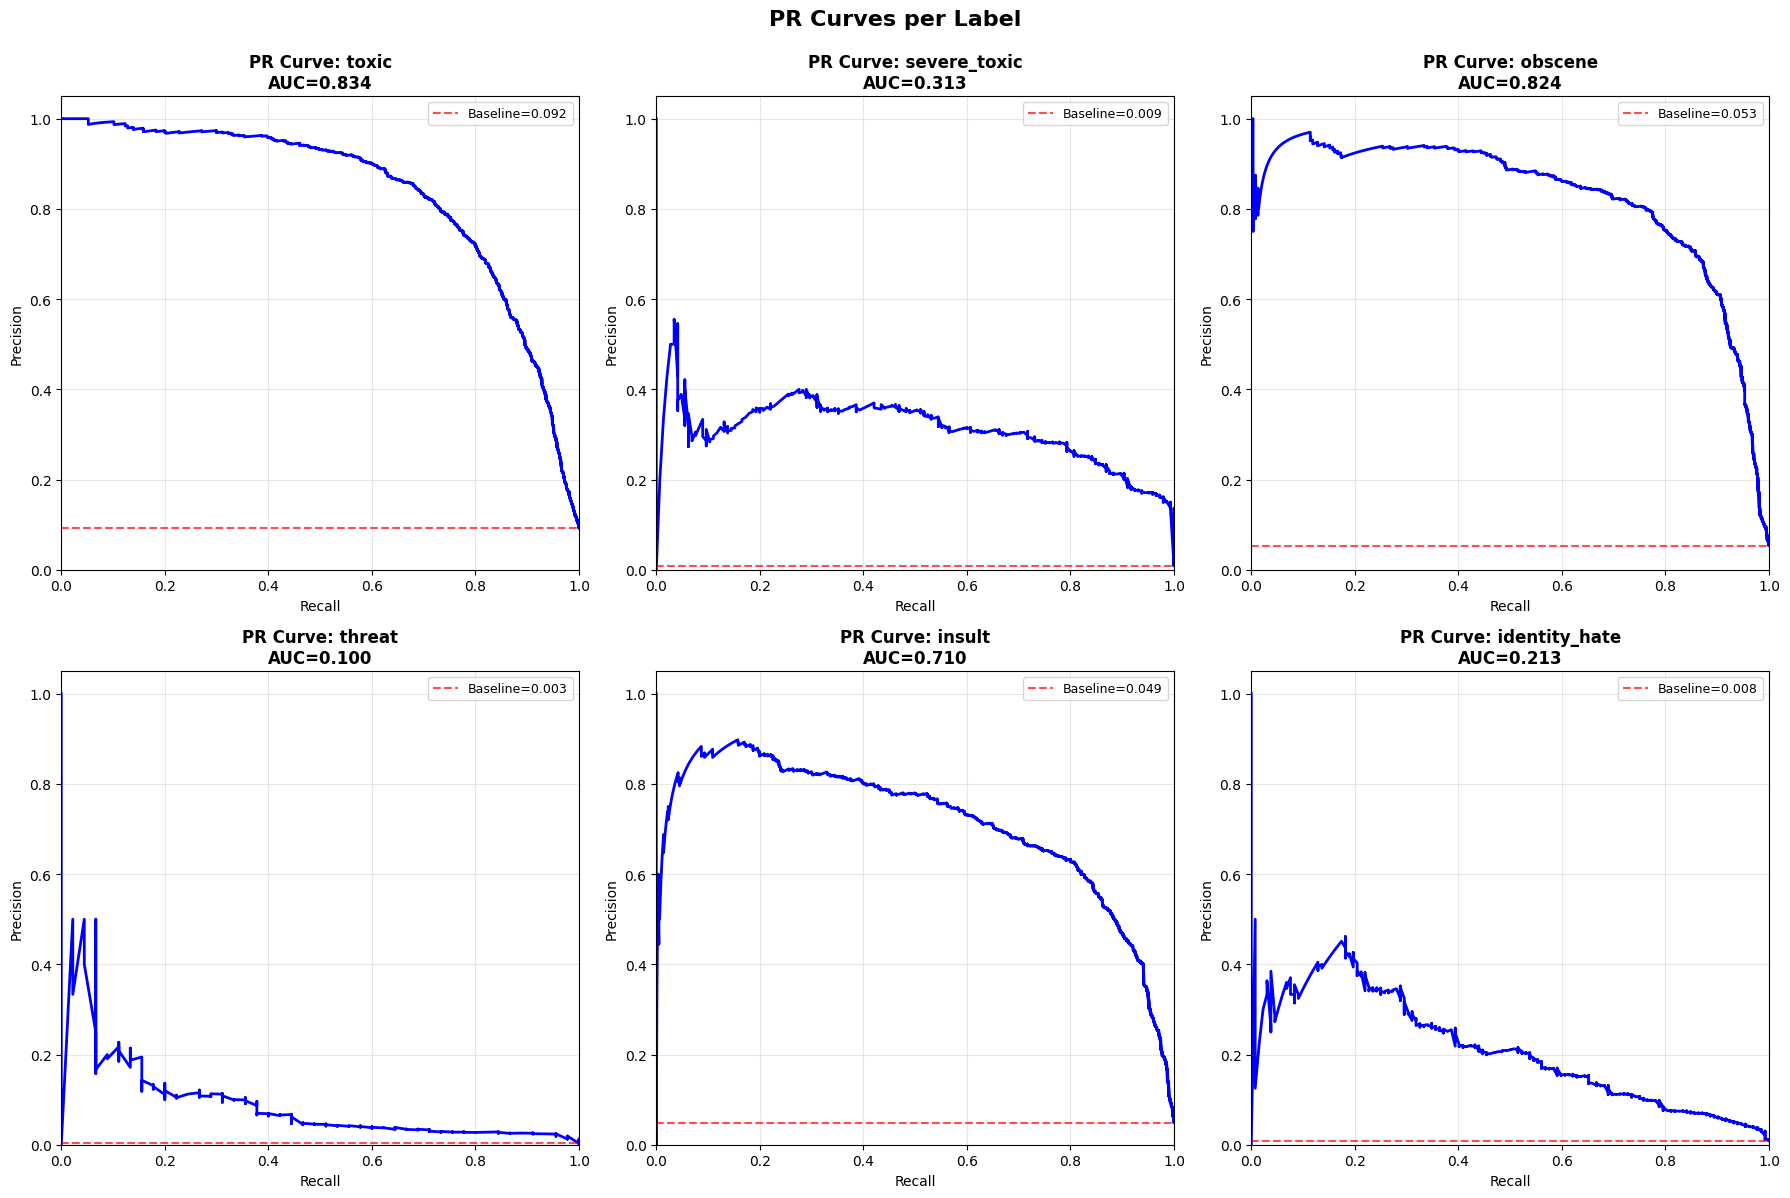

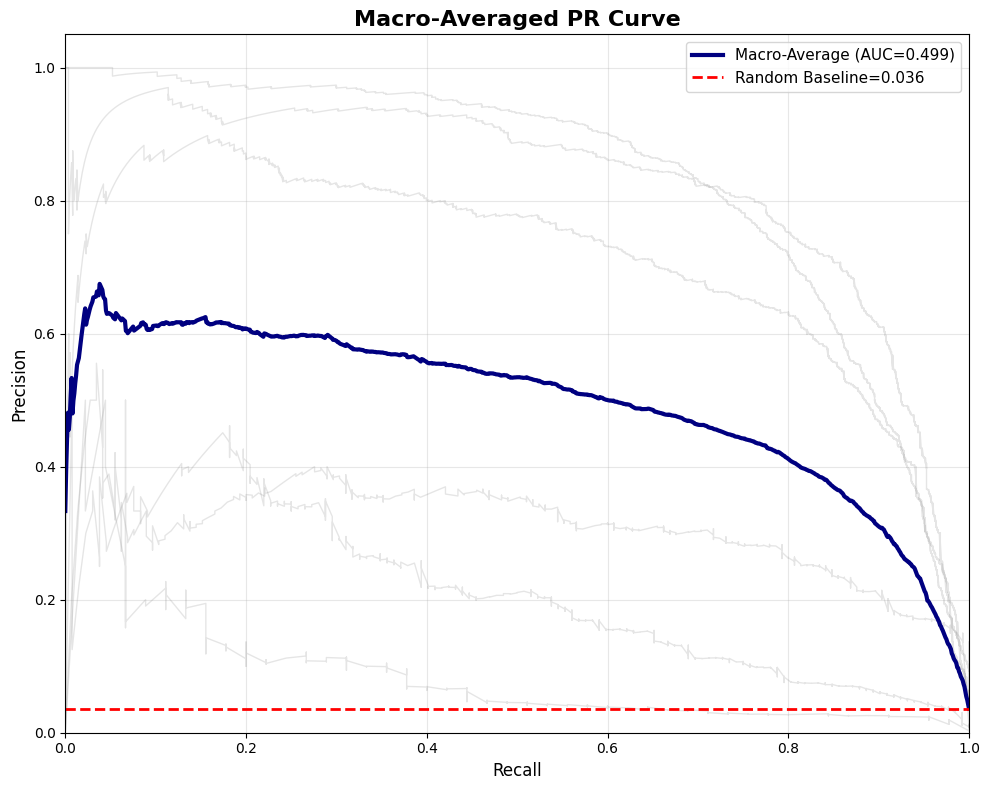


Computing F1 scores across thresholds...


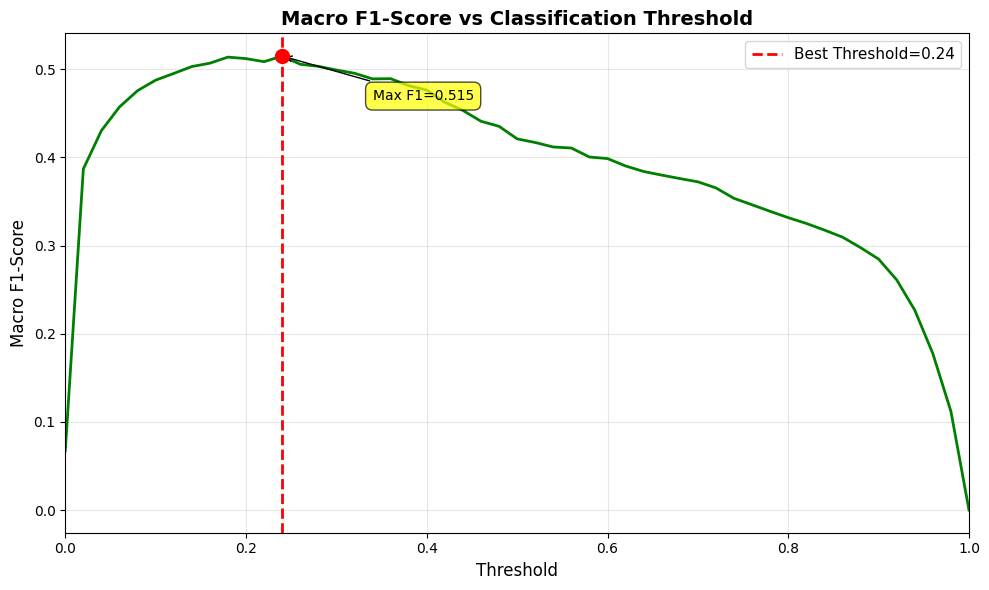

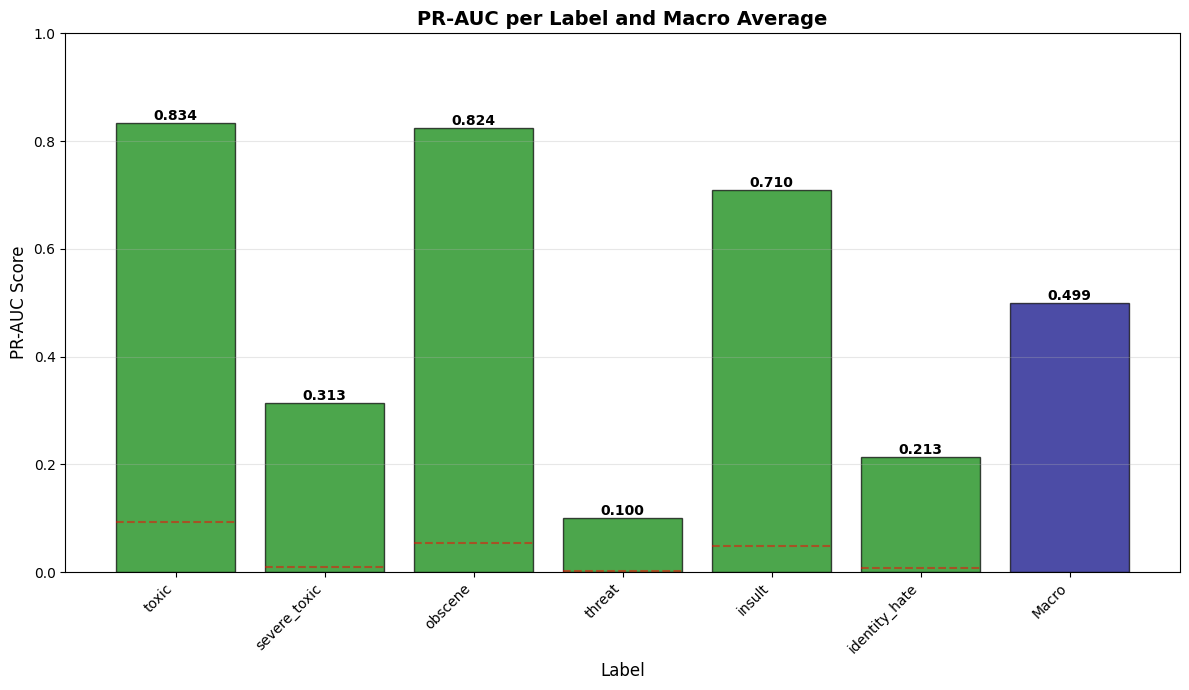


VALIDATION METRICS SUMMARY

Macro-Averaged PR-AUC: 0.4990
Best F1 Threshold:     0.24
Best Macro F1-Score:   0.5151

Per-Label PR-AUC Scores:
----------------------------------------------------------------------
  toxic           | PR-AUC: 0.8339 | Baseline: 0.0924 | Δ: +0.7416
  severe_toxic    | PR-AUC: 0.3135 | Baseline: 0.0091 | Δ: +0.3044
  obscene         | PR-AUC: 0.8237 | Baseline: 0.0533 | Δ: +0.7703
  threat          | PR-AUC: 0.1000 | Baseline: 0.0028 | Δ: +0.0971
  insult          | PR-AUC: 0.7097 | Baseline: 0.0489 | Δ: +0.6607
  identity_hate   | PR-AUC: 0.2131 | Baseline: 0.0083 | Δ: +0.2048

Macro PR-AUC: 0.4990
Use threshold: 0.24 for classification


In [44]:
results = plot_pr_auc_and_f1(model, valid_loader, device)
# Access results
print(f"Macro PR-AUC: {results['macro_pr_auc']:.4f}")
print(f"Use threshold: {results['best_f1_threshold']:.2f} for classification")

## Stacked GRU

In [45]:
class StackedGRUModel(nn.Module):
    def __init__(self, vocab_size=30522, embed_dim=256, n_layers=1,
                 hidden_dim=32, pad_id=0, dropout=0.0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_dim, 6)

    def forward(self, encodings):
        embeddings = self.embed(encodings["input_ids"])
        lengths = encodings["attention_mask"].sum(dim=1)                      
        packed = pack_padded_sequence(embeddings, lengths=lengths.cpu(),      
                                      batch_first=True, enforce_sorted=False) 
        _outputs, h_n  = self.gru(packed) 
        return self.output(h_n[-1])

In [46]:
base_config = {
    # Model architecture
    "model_type": "Stacked GRU",
    "embed_dim": 256,
    "hidden_dim": 32,
    "num_layers": 1,
    "dropout": 0.0,
    
    # Training
    "learning_rate": 0.001,
    "batch_size": 256,
    "optimizer": "AdamW",
    "sched_patience" : 2,
    "sched_factor": 0.5,
    "max_grad_norm": 1.0,
    "start_epoch": 0,
    "end_epoch": 10
}

### Config_1 Training

In [47]:
# Setup New Config
config = deepcopy(base_config)

model = StackedGRUModel(
    vocab_size=len(tokenizer),
    embed_dim=config["embed_dim"],
    n_layers=config["num_layers"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

# Training configuration
xentropy = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

# Metric (move to device!)
macro_pr_auc = MultilabelAveragePrecision(
    num_labels=6,
    average="macro"
).to(device)

# Train
with wandb.init(project="nontoxic-world",
                name="from-scratch-stacked-gru-config-2",
                config=config,
                notes="set hidden_dim=16"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_gru_model.pth'
    )

Epoch 1/10, train loss: 0.1485, train metric: 15.15%, valid metric: 44.95% [BEST]
Epoch 2/10, train loss: 0.0615, train metric: 48.89%, valid metric: 50.33% [BEST]
Epoch 3/10, train loss: 0.0481, train metric: 54.82%, valid metric: 52.35% [BEST]
Epoch 4/10, train loss: 0.0414, train metric: 59.30%, valid metric: 53.16% [BEST]
Epoch 5/10, train loss: 0.0364, train metric: 63.24%, valid metric: 53.62% [BEST]
Epoch 6/10, train loss: 0.0325, train metric: 67.04%, valid metric: 53.74% [BEST]
Epoch 7/10, train loss: 0.0294, train metric: 70.24%, valid metric: 53.58% 
Epoch 8/10, train loss: 0.0269, train metric: 73.32%, valid metric: 54.20% [BEST]
Epoch 9/10, train loss: 0.0246, train metric: 76.36%, valid metric: 53.52% 
Epoch 10/10, train loss: 0.0224, train metric: 79.58%, valid metric: 53.99% 


epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▃▂▂▂▂▁▁▁▁
train/pr_auc,▁▅▅▆▆▇▇▇██
val/pr_auc,▁▅▇▇████▇█
epoch,9.1
train/loss,0.02239
train/pr_auc,0.7958
val/pr_auc,0.53992


## Stacked Bidirectional LSTM

In [49]:
class StackedBiLSTMModel(nn.Module):
    def __init__(self, vocab_size=30522, embed_dim=256, n_layers=1,
                 hidden_dim=32, pad_id=0, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.output = nn.Linear(2 * hidden_dim, 6)

    def forward(self, encodings):
        embeddings = self.embed(encodings["input_ids"])
        lengths = encodings["attention_mask"].sum(dim=1)                      
        packed = pack_padded_sequence(embeddings, lengths=lengths.cpu(),      
                                      batch_first=True, enforce_sorted=False) 
        _outputs, (h_n, c_n) = self.lstm(packed) 

        n_dims = self.output.in_features # added
        top_states = h_n[-2:].permute(1, 0, 2).reshape(-1, n_dims) # added
        return self.output(top_states) # added

In [50]:
base_config = {
    # Model architecture
    "model_type": "Stacked BiLSTM",
    "embed_dim": 256,
    "hidden_dim": 32,
    "num_layers": 1,
    "dropout": 0.0,
    
    # Training
    "learning_rate": 0.001,
    "batch_size": 256,
    "optimizer": "AdamW",
    "sched_patience" : 2,
    "sched_factor": 0.5,
    "max_grad_norm": 1.0,
    "start_epoch": 0,
    "end_epoch": 10
}

### Config_1 Training

In [51]:
# Setup New Config
config = deepcopy(base_config)

model = StackedBiLSTMModel(
    vocab_size=len(tokenizer),
    embed_dim=config["embed_dim"],
    n_layers=config["num_layers"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

# Training configuration
xentropy = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

# Metric (move to device!)
macro_pr_auc = MultilabelAveragePrecision(
    num_labels=6,
    average="macro"
).to(device)

# Train
with wandb.init(project="nontoxic-world",
                name="from-scratch-stacked-bilstm-config-1",
                config=config,
                notes="base config"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_bilstm_model.pth'
    )

Epoch 1/10, train loss: 0.1324, train metric: 20.47%, valid metric: 45.87% [BEST]
Epoch 2/10, train loss: 0.0599, train metric: 49.50%, valid metric: 50.92% [BEST]
Epoch 3/10, train loss: 0.0480, train metric: 54.91%, valid metric: 52.55% [BEST]
Epoch 4/10, train loss: 0.0417, train metric: 58.87%, valid metric: 53.69% [BEST]
Epoch 5/10, train loss: 0.0365, train metric: 62.27%, valid metric: 54.39% [BEST]
Epoch 6/10, train loss: 0.0324, train metric: 65.86%, valid metric: 54.07% 
Epoch 7/10, train loss: 0.0291, train metric: 69.56%, valid metric: 54.75% [BEST]
Epoch 8/10, train loss: 0.0264, train metric: 73.07%, valid metric: 54.41% 
Epoch 9/10, train loss: 0.0237, train metric: 77.04%, valid metric: 55.34% [BEST]
Epoch 10/10, train loss: 0.0211, train metric: 80.77%, valid metric: 55.68% [BEST]


epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▃▃▂▂▂▂▁▁▁
train/pr_auc,▁▄▅▅▆▆▇▇██
val/pr_auc,▁▅▆▇▇▇▇▇██
epoch,10
train/loss,0.02112
train/pr_auc,0.80771
val/pr_auc,0.55685


### Config_2 Training

In [52]:
# Setup New Config
config = deepcopy(base_config)
config["num_layers"] = 2
config["dropout"] = 0.4

model = StackedBiLSTMModel(
    vocab_size=len(tokenizer),
    embed_dim=config["embed_dim"],
    n_layers=config["num_layers"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

# Training configuration
xentropy = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

# Metric (move to device!)
macro_pr_auc = MultilabelAveragePrecision(
    num_labels=6,
    average="macro"
).to(device)

# Train
with wandb.init(project="nontoxic-world",
                name="from-scratch-stacked-bilstm-config-2",
                config=config,
                notes="set num_layers=2, dropout=0.4"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_bilstm_model-2.pth'
    )

Epoch 1/10, train loss: 0.1192, train metric: 23.85%, valid metric: 48.16% [BEST]
Epoch 2/10, train loss: 0.0554, train metric: 49.94%, valid metric: 51.85% [BEST]
Epoch 3/10, train loss: 0.0461, train metric: 53.53%, valid metric: 53.21% [BEST]
Epoch 4/10, train loss: 0.0411, train metric: 55.53%, valid metric: 54.16% [BEST]
Epoch 5/10, train loss: 0.0376, train metric: 57.73%, valid metric: 55.07% [BEST]
Epoch 6/10, train loss: 0.0342, train metric: 59.96%, valid metric: 55.44% [BEST]
Epoch 7/10, train loss: 0.0311, train metric: 62.89%, valid metric: 55.74% [BEST]
Epoch 8/10, train loss: 0.0284, train metric: 65.67%, valid metric: 56.39% [BEST]
Epoch 9/10, train loss: 0.0260, train metric: 68.78%, valid metric: 57.41% [BEST]
Epoch 10/10, train loss: 0.0240, train metric: 72.99%, valid metric: 58.66% [BEST]


epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▃▃▂▂▂▂▁▁▁
train/pr_auc,▁▅▅▆▆▆▇▇▇█
val/pr_auc,▁▃▄▅▆▆▆▆▇█
epoch,10
train/loss,0.02403
train/pr_auc,0.72992
val/pr_auc,0.58657


✓ Collected 15957 samples


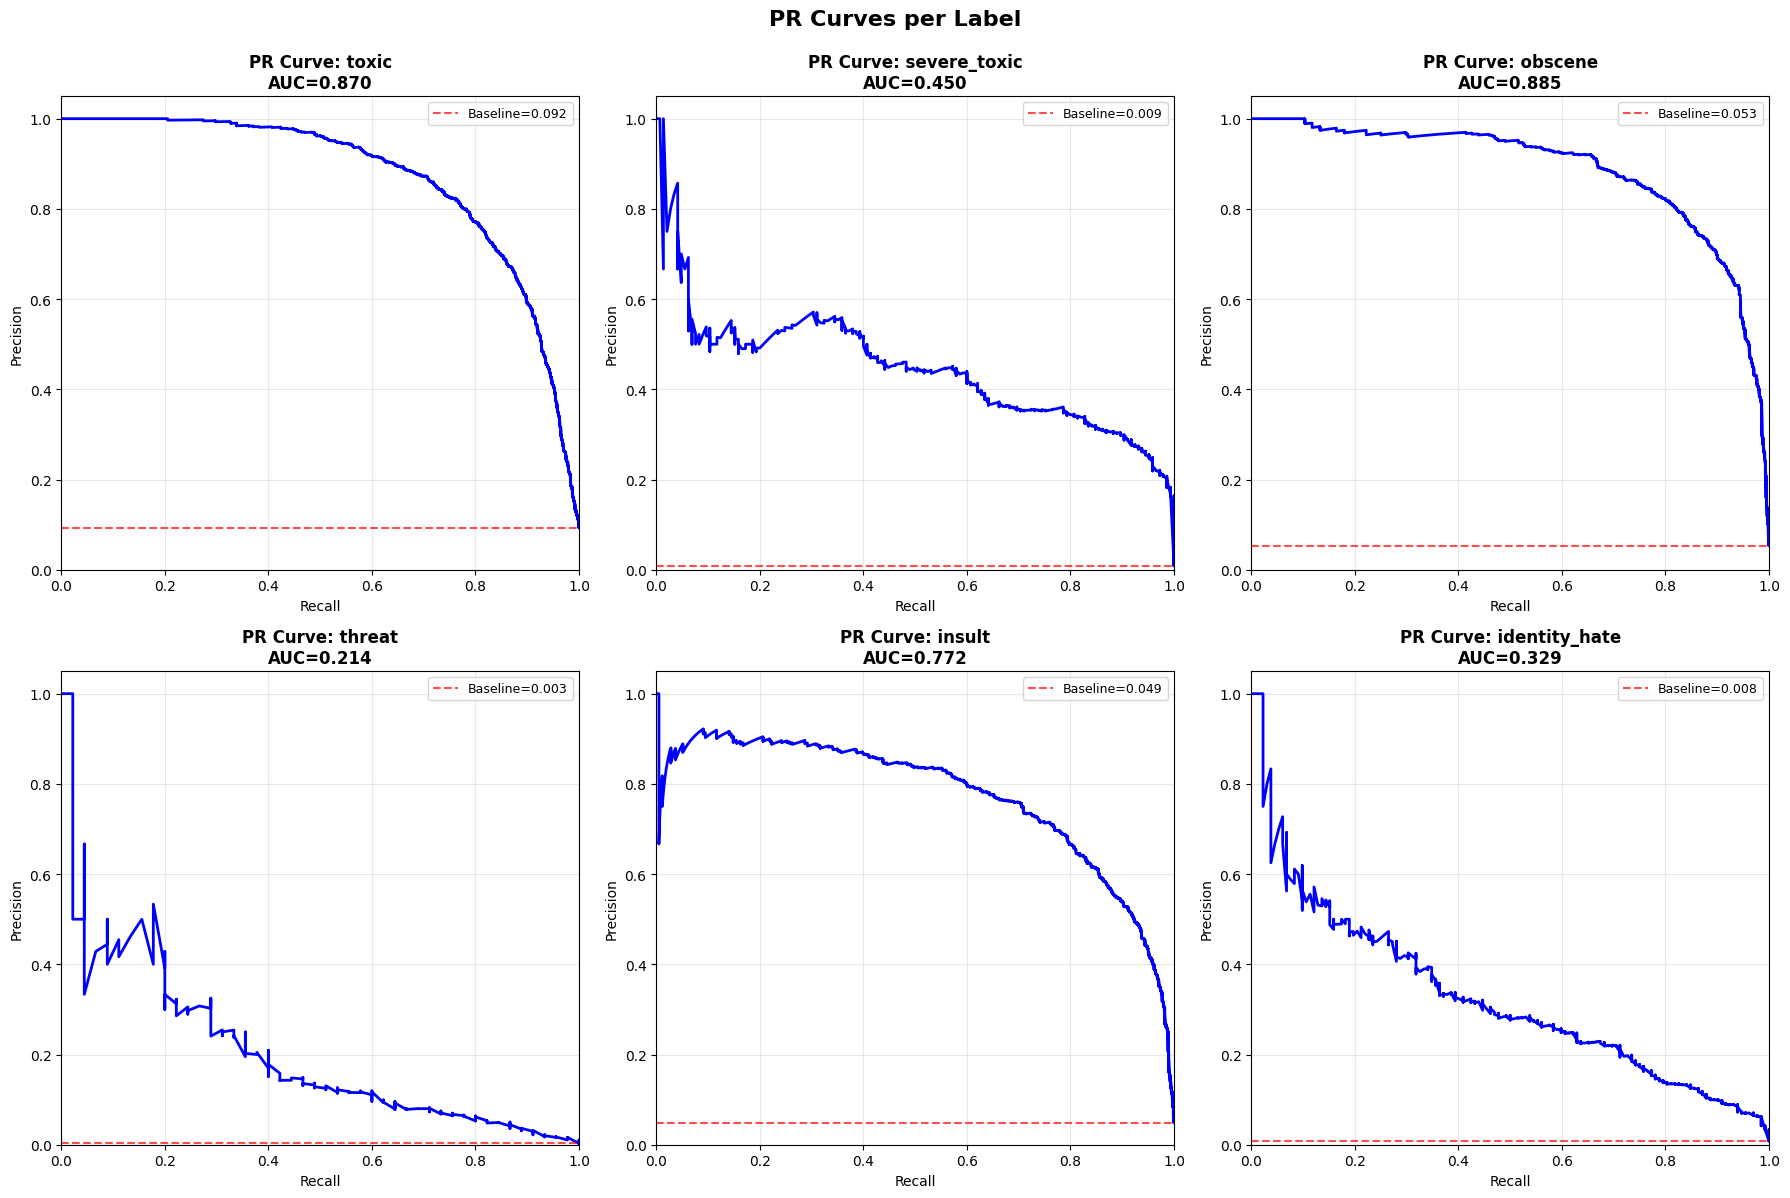

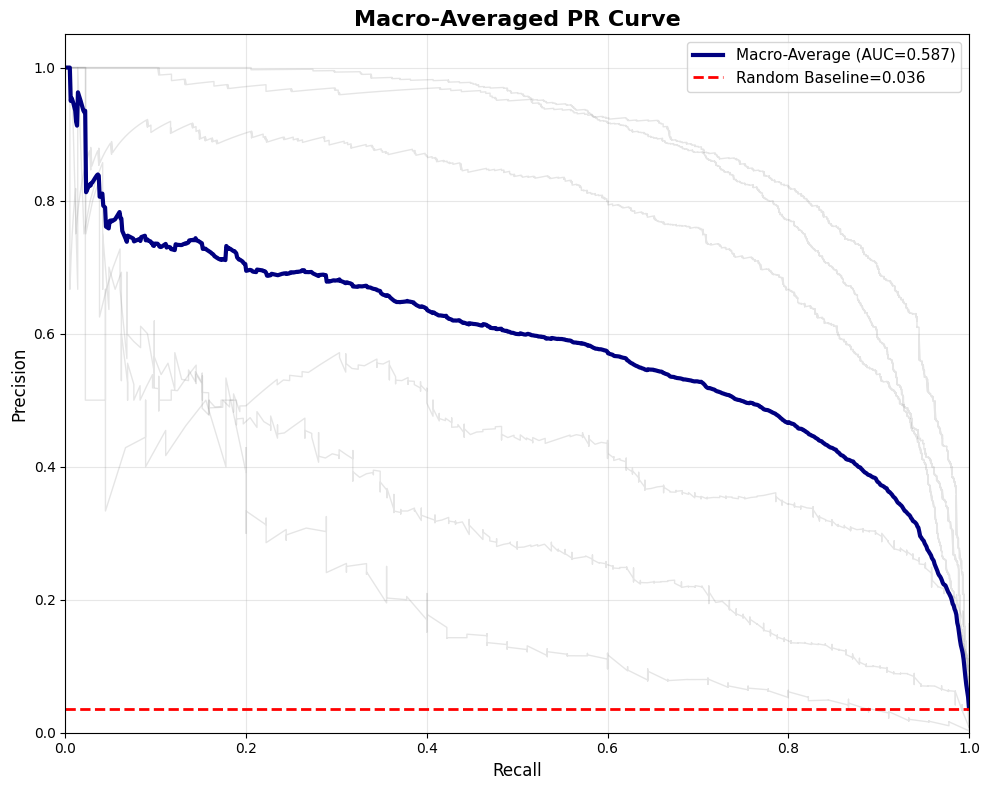


Computing F1 scores across thresholds...


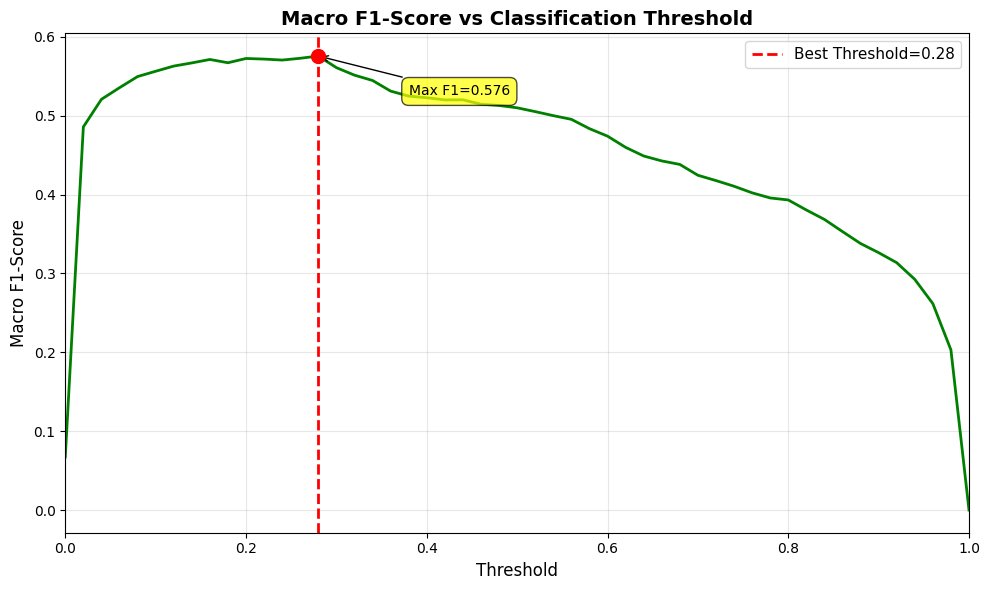

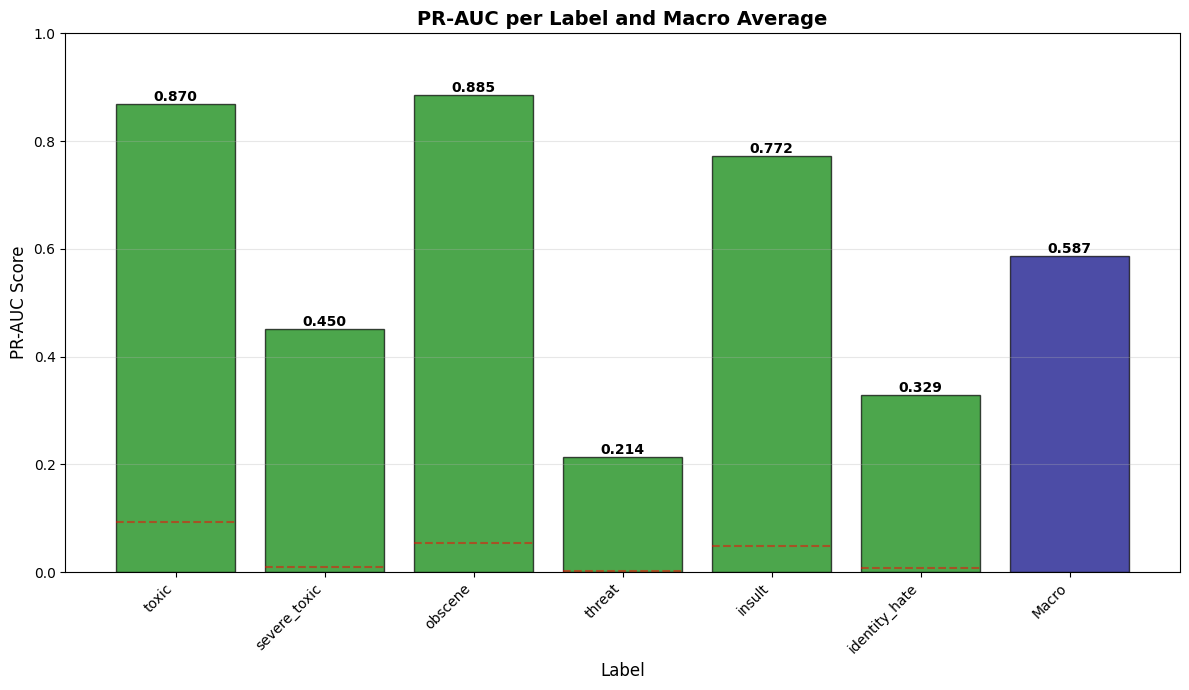


VALIDATION METRICS SUMMARY

Macro-Averaged PR-AUC: 0.5866
Best F1 Threshold:     0.28
Best Macro F1-Score:   0.5757

Per-Label PR-AUC Scores:
----------------------------------------------------------------------
  toxic           | PR-AUC: 0.8695 | Baseline: 0.0924 | Δ: +0.7772
  severe_toxic    | PR-AUC: 0.4503 | Baseline: 0.0091 | Δ: +0.4412
  obscene         | PR-AUC: 0.8852 | Baseline: 0.0533 | Δ: +0.8319
  threat          | PR-AUC: 0.2137 | Baseline: 0.0028 | Δ: +0.2109
  insult          | PR-AUC: 0.7722 | Baseline: 0.0489 | Δ: +0.7233
  identity_hate   | PR-AUC: 0.3285 | Baseline: 0.0083 | Δ: +0.3202

Macro PR-AUC: 0.5866
Use threshold: 0.28 for classification


In [53]:
results = plot_pr_auc_and_f1(model, valid_loader, device)
# Access results
print(f"Macro PR-AUC: {results['macro_pr_auc']:.4f}")
print(f"Use threshold: {results['best_f1_threshold']:.2f} for classification")

## Stacked Bidirectional GRU

In [54]:
class StackedBiGRUModel(nn.Module):
    def __init__(self, vocab_size=30522, embed_dim=256, n_layers=1,
                 hidden_dim=32, pad_id=0, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.output = nn.Linear(2 * hidden_dim, 6)

    def forward(self, encodings):
        embeddings = self.embed(encodings["input_ids"])
        lengths = encodings["attention_mask"].sum(dim=1)                      
        packed = pack_padded_sequence(embeddings, lengths=lengths.cpu(),      
                                      batch_first=True, enforce_sorted=False) 
        _outputs, h_n  = self.gru(packed) 

        n_dims = self.output.in_features # added
        top_states = h_n[-2:].permute(1, 0, 2).reshape(-1, n_dims) # added
        return self.output(top_states) # added

In [55]:
base_config = {
    # Model architecture
    "model_type": "Stacked BiGRU",
    "embed_dim": 256,
    "hidden_dim": 32,
    "num_layers": 1,
    "dropout": 0.0,
    
    # Training
    "learning_rate": 0.001,
    "batch_size": 256,
    "optimizer": "AdamW",
    "sched_patience" : 2,
    "sched_factor": 0.5,
    "max_grad_norm": 1.0,
    "start_epoch": 0,
    "end_epoch": 10
}

### Config_1 Training

In [56]:
# Setup New Config
config = deepcopy(base_config)

model = StackedBiGRUModel(
    vocab_size=len(tokenizer),
    embed_dim=config["embed_dim"],
    n_layers=config["num_layers"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

# Training configuration
xentropy = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

# Metric (move to device!)
macro_pr_auc = MultilabelAveragePrecision(
    num_labels=6,
    average="macro"
).to(device)

# Train
with wandb.init(project="nontoxic-world",
                name="from-scratch-stacked-bigru-config-1",
                config=config,
                notes="base config"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_bigru_model.pth'
    )

Epoch 1/10, train loss: 0.1221, train metric: 23.05%, valid metric: 48.31% [BEST]
Epoch 2/10, train loss: 0.0550, train metric: 52.28%, valid metric: 53.42% [BEST]
Epoch 3/10, train loss: 0.0433, train metric: 58.59%, valid metric: 55.72% [BEST]
Epoch 4/10, train loss: 0.0362, train metric: 64.29%, valid metric: 56.53% [BEST]
Epoch 5/10, train loss: 0.0308, train metric: 69.53%, valid metric: 56.91% [BEST]
Epoch 6/10, train loss: 0.0265, train metric: 74.92%, valid metric: 57.86% [BEST]
Epoch 7/10, train loss: 0.0229, train metric: 79.53%, valid metric: 58.15% [BEST]
Epoch 8/10, train loss: 0.0198, train metric: 83.39%, valid metric: 57.88% 
Epoch 9/10, train loss: 0.0171, train metric: 86.86%, valid metric: 57.63% 
Epoch 10/10, train loss: 0.0147, train metric: 90.16%, valid metric: 57.36% 


epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▄▃▂▂▂▂▁▁▁
train/pr_auc,▁▄▅▅▆▆▇▇██
val/pr_auc,▁▅▆▇▇████▇
epoch,10
train/loss,0.01466
train/pr_auc,0.90161
val/pr_auc,0.57364


### Config_2 Training

In [57]:
# Setup New Config
config = deepcopy(base_config)
config["num_layers"] = 2
config["dropout"] = 0.4

model = StackedBiGRUModel(
    vocab_size=len(tokenizer),
    embed_dim=config["embed_dim"],
    n_layers=config["num_layers"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

# Training configuration
xentropy = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

# Metric (move to device!)
macro_pr_auc = MultilabelAveragePrecision(
    num_labels=6,
    average="macro"
).to(device)

# Train
with wandb.init(project="nontoxic-world",
                name="from-scratch-stacked-bigru-config-2",
                config=config,
                notes="set num_layers=2, dropout=0.4"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_bigru_model.pth'
    )

Epoch 1/10, train loss: 0.1091, train metric: 30.73%, valid metric: 51.58% [BEST]
Epoch 2/10, train loss: 0.0496, train metric: 53.35%, valid metric: 54.65% [BEST]
Epoch 3/10, train loss: 0.0424, train metric: 56.49%, valid metric: 56.07% [BEST]
Epoch 4/10, train loss: 0.0373, train metric: 59.39%, valid metric: 57.76% [BEST]
Epoch 5/10, train loss: 0.0331, train metric: 62.85%, valid metric: 58.67% [BEST]
Epoch 6/10, train loss: 0.0296, train metric: 65.72%, valid metric: 59.66% [BEST]
Epoch 7/10, train loss: 0.0267, train metric: 69.63%, valid metric: 60.90% [BEST]
Epoch 8/10, train loss: 0.0243, train metric: 72.81%, valid metric: 61.40% [BEST]
Epoch 9/10, train loss: 0.0221, train metric: 76.00%, valid metric: 61.19% 
Epoch 10/10, train loss: 0.0200, train metric: 79.67%, valid metric: 61.81% [BEST]


epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▃▃▂▂▂▂▁▁▁
train/pr_auc,▁▄▅▅▆▆▇▇▇█
val/pr_auc,▁▃▄▅▆▇▇███
epoch,10
train/loss,0.01996
train/pr_auc,0.79674
val/pr_auc,0.6181


✓ Collected 15957 samples


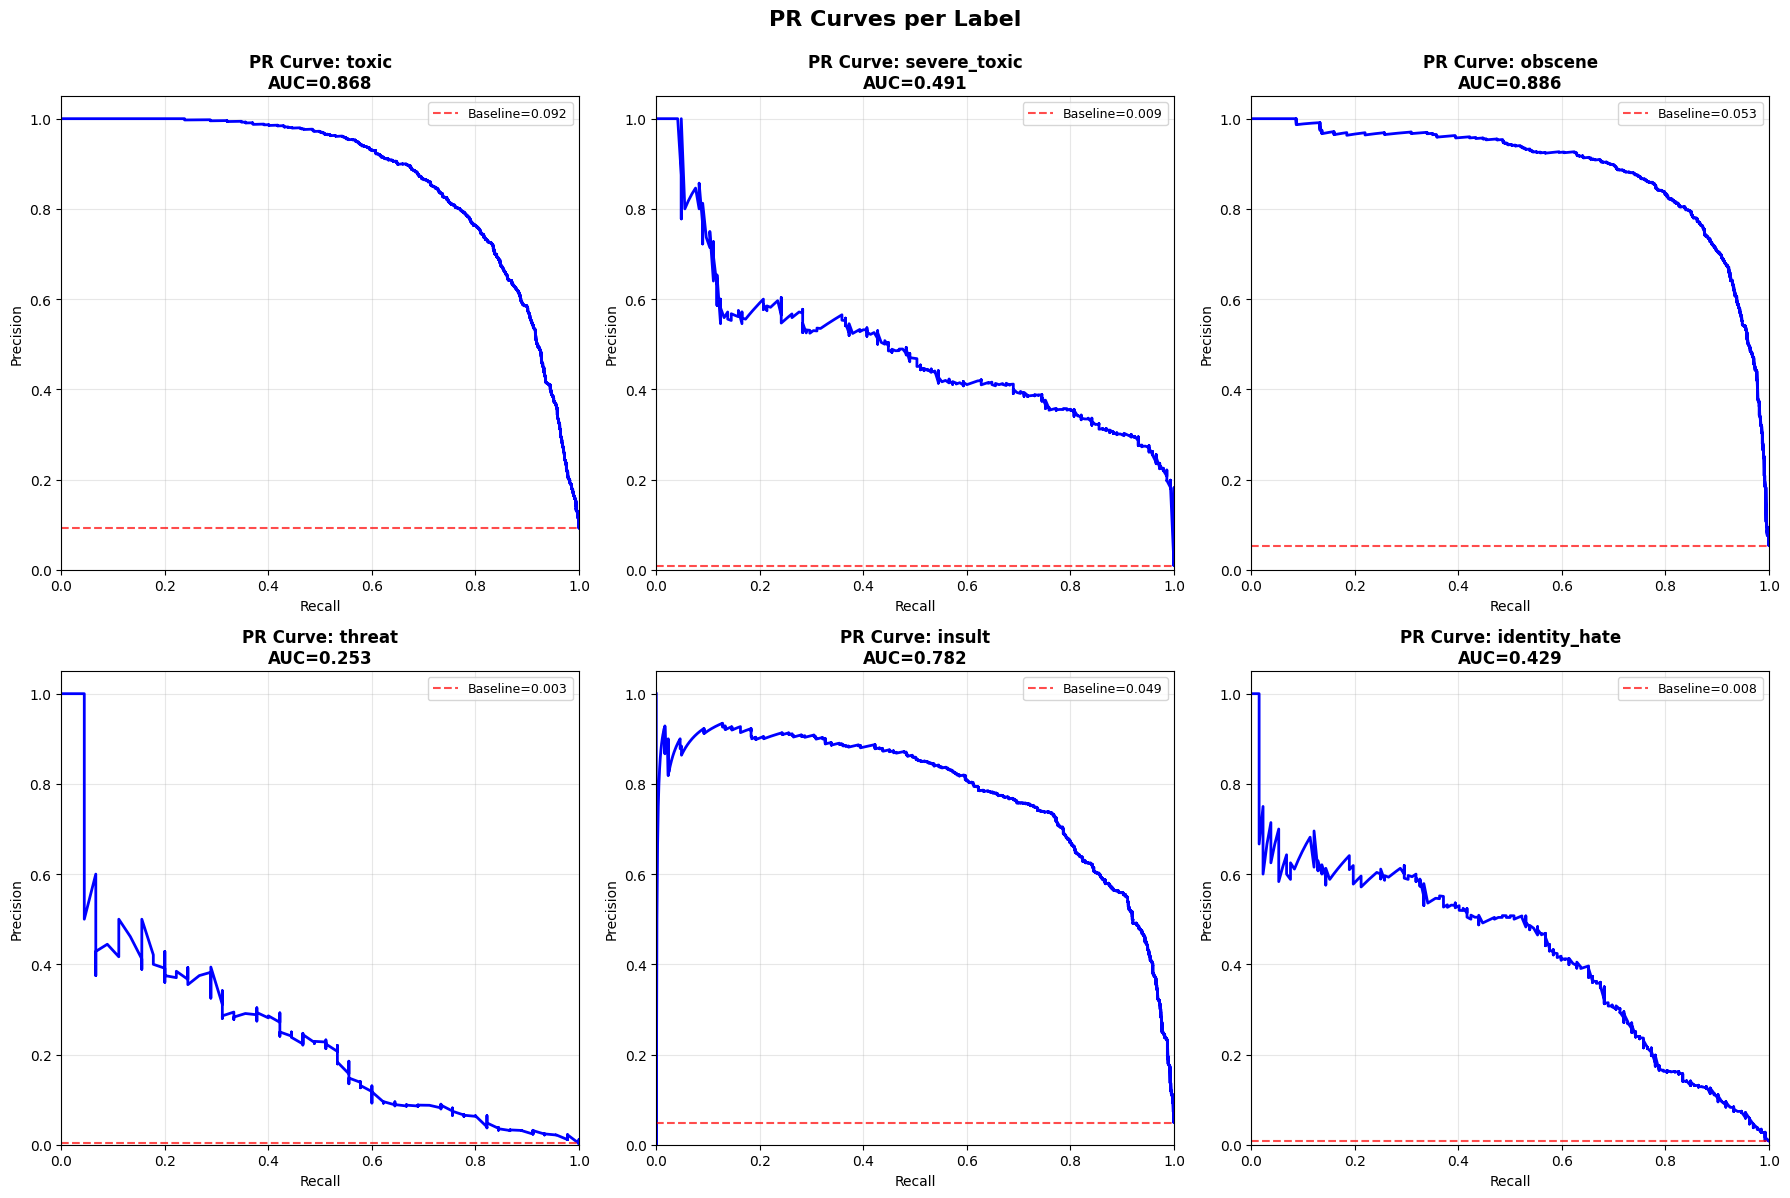

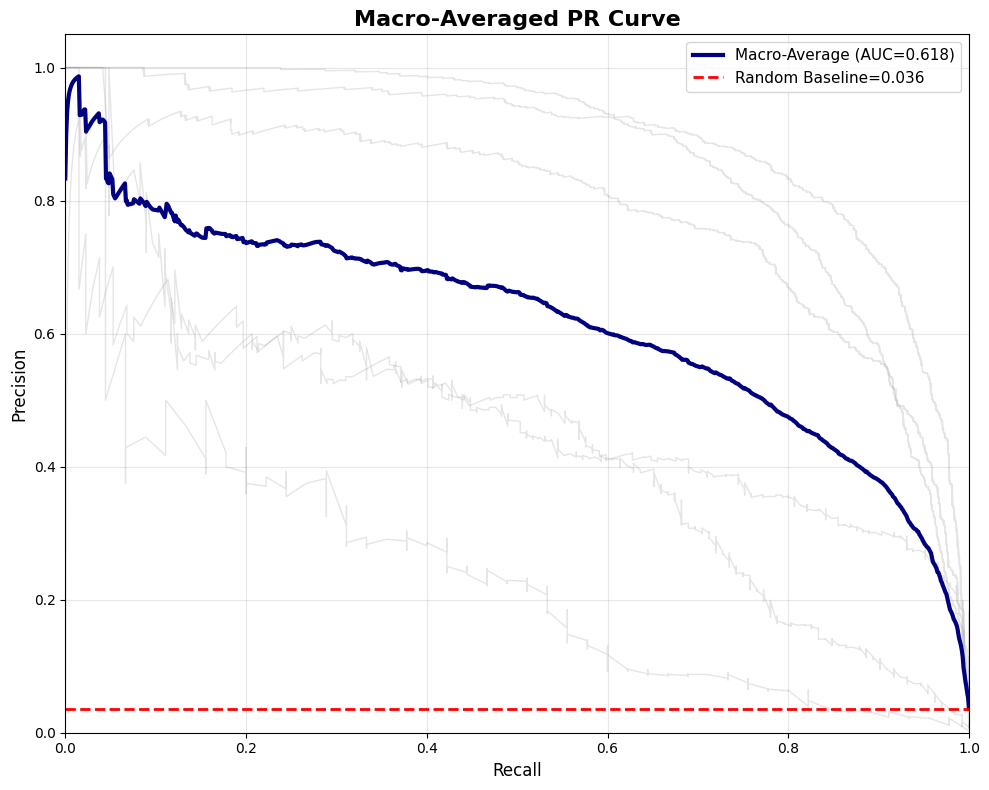


Computing F1 scores across thresholds...


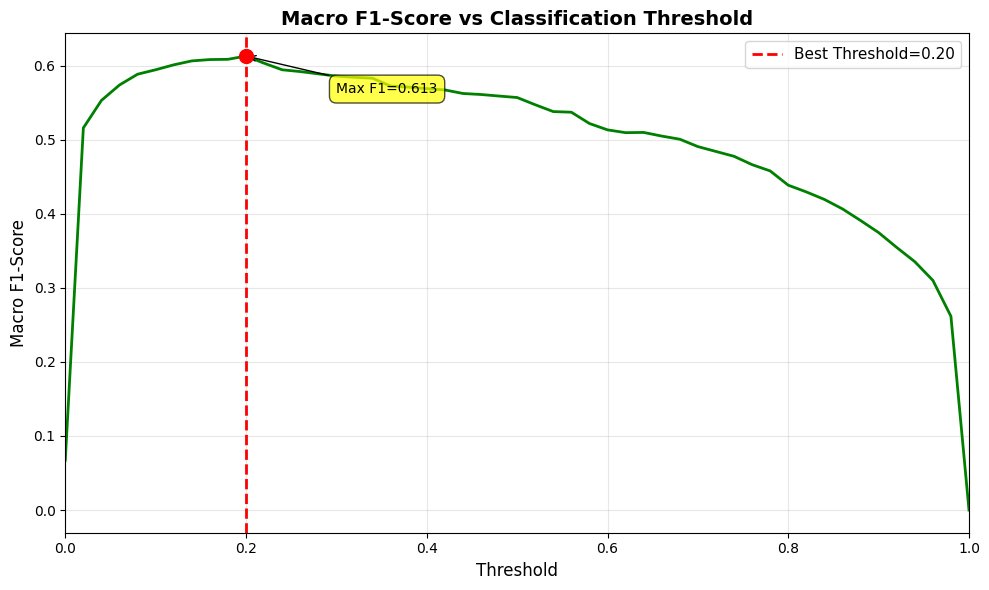

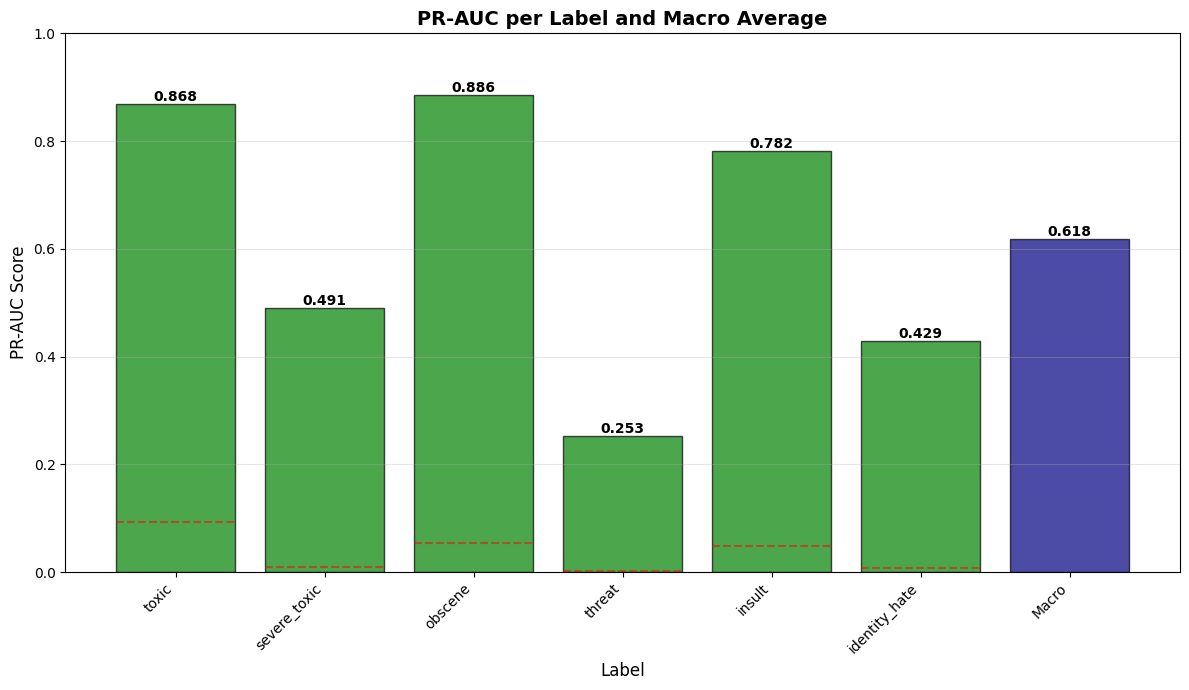


VALIDATION METRICS SUMMARY

Macro-Averaged PR-AUC: 0.6181
Best F1 Threshold:     0.20
Best Macro F1-Score:   0.6130

Per-Label PR-AUC Scores:
----------------------------------------------------------------------
  toxic           | PR-AUC: 0.8680 | Baseline: 0.0924 | Δ: +0.7756
  severe_toxic    | PR-AUC: 0.4909 | Baseline: 0.0091 | Δ: +0.4818
  obscene         | PR-AUC: 0.8863 | Baseline: 0.0533 | Δ: +0.8330
  threat          | PR-AUC: 0.2529 | Baseline: 0.0028 | Δ: +0.2501
  insult          | PR-AUC: 0.7817 | Baseline: 0.0489 | Δ: +0.7328
  identity_hate   | PR-AUC: 0.4289 | Baseline: 0.0083 | Δ: +0.4206

Macro PR-AUC: 0.6181
Use threshold: 0.20 for classification


In [58]:
results = plot_pr_auc_and_f1(model, valid_loader, device)
# Access results
print(f"Macro PR-AUC: {results['macro_pr_auc']:.4f}")
print(f"Use threshold: {results['best_f1_threshold']:.2f} for classification")

In [60]:
# Train more 10 epochs:
config["start_epoch"] = 10
config["end_epoch"] = 20

with wandb.init(project="nontoxic-world",
                id="84bepott",
                config=config,
                resume="allow"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_bigru_model_2.pth'
    )

Epoch 11/20, train loss: 0.0181, train metric: 82.65%, valid metric: 62.09% [BEST]
Epoch 12/20, train loss: 0.0164, train metric: 85.32%, valid metric: 62.53% [BEST]
Epoch 13/20, train loss: 0.0148, train metric: 87.63%, valid metric: 61.50% 
Epoch 14/20, train loss: 0.0134, train metric: 89.41%, valid metric: 60.60% 
Epoch 15/20, train loss: 0.0119, train metric: 90.74%, valid metric: 60.75% 
Epoch 16/20, train loss: 0.0097, train metric: 93.29%, valid metric: 61.34% 
Epoch 18/20, train loss: 0.0076, train metric: 94.96%, valid metric: 60.11% 
Epoch 19/20, train loss: 0.0066, train metric: 95.80%, valid metric: 60.12% 
Epoch 20/20, train loss: 0.0061, train metric: 96.22%, valid metric: 59.68% 


epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▇▆▅▄▃▂▂▁▁
train/pr_auc,▁▂▄▄▅▆▇▇██
val/pr_auc,▇█▅▃▄▅▃▂▂▁
epoch,20
train/loss,0.00611
train/pr_auc,0.96221
val/pr_auc,0.59685


### Config_3 Training

In [66]:
# Setup New Config
config = deepcopy(base_config)
config["num_layers"] = 2
config["dropout"] = 0.5
config["end_epoch"] = 5

model = StackedBiGRUModel(
    vocab_size=len(tokenizer),
    embed_dim=config["embed_dim"],
    n_layers=config["num_layers"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

# Training configuration
xentropy = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

# Metric (move to device!)
macro_pr_auc = MultilabelAveragePrecision(
    num_labels=6,
    average="macro"
).to(device)

# Train
with wandb.init(project="nontoxic-world",
                name="from-scratch-stacked-bigru-config-3",
                config=config,
                notes="set num_layers=2, dropout=0.5, 5 epochs without freezing embedding and 10 with freeze"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_bigru_model_3.pth'
    )

Epoch 1/5, train loss: 0.1093, train metric: 29.89%, valid metric: 51.67% [BEST]
Epoch 2/5, train loss: 0.0505, train metric: 52.63%, valid metric: 54.25% [BEST]
Epoch 3/5, train loss: 0.0431, train metric: 55.74%, valid metric: 55.44% [BEST]
Epoch 4/5, train loss: 0.0382, train metric: 58.17%, valid metric: 56.83% [BEST]
Epoch 5/5, train loss: 0.0343, train metric: 61.59%, valid metric: 57.99% [BEST]


epoch,▁▃▅▆█
train/loss,█▃▂▁▁
train/pr_auc,▁▆▇▇█
val/pr_auc,▁▄▅▇█
epoch,5
train/loss,0.03426
train/pr_auc,0.61587
val/pr_auc,0.57985


In [67]:
for param in model.embed.parameters():
    param.requires_grad = False

# Train more 10 epochs:
config["start_epoch"] = 5
config["end_epoch"] = 10

with wandb.init(project="nontoxic-world",
                id="h8qg1wsu",
                config=config,
                resume="allow"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_bigru_model_4.pth'
    )

Epoch 6/10, train loss: 0.0304, train metric: 64.65%, valid metric: 59.78% [BEST]
Epoch 7/10, train loss: 0.0286, train metric: 67.52%, valid metric: 60.45% [BEST]
Epoch 8/10, train loss: 0.0272, train metric: 69.77%, valid metric: 61.67% [BEST]
Epoch 9/10, train loss: 0.0260, train metric: 72.43%, valid metric: 62.00% [BEST]
Epoch 10/10, train loss: 0.0249, train metric: 74.95%, valid metric: 62.21% [BEST]


epoch,▁▃▅▆█
train/loss,█▆▄▂▁
train/pr_auc,▁▃▄▆█
val/pr_auc,▁▃▆▇█
epoch,10
train/loss,0.02492
train/pr_auc,0.74953
val/pr_auc,0.62215


✓ Collected 15957 samples


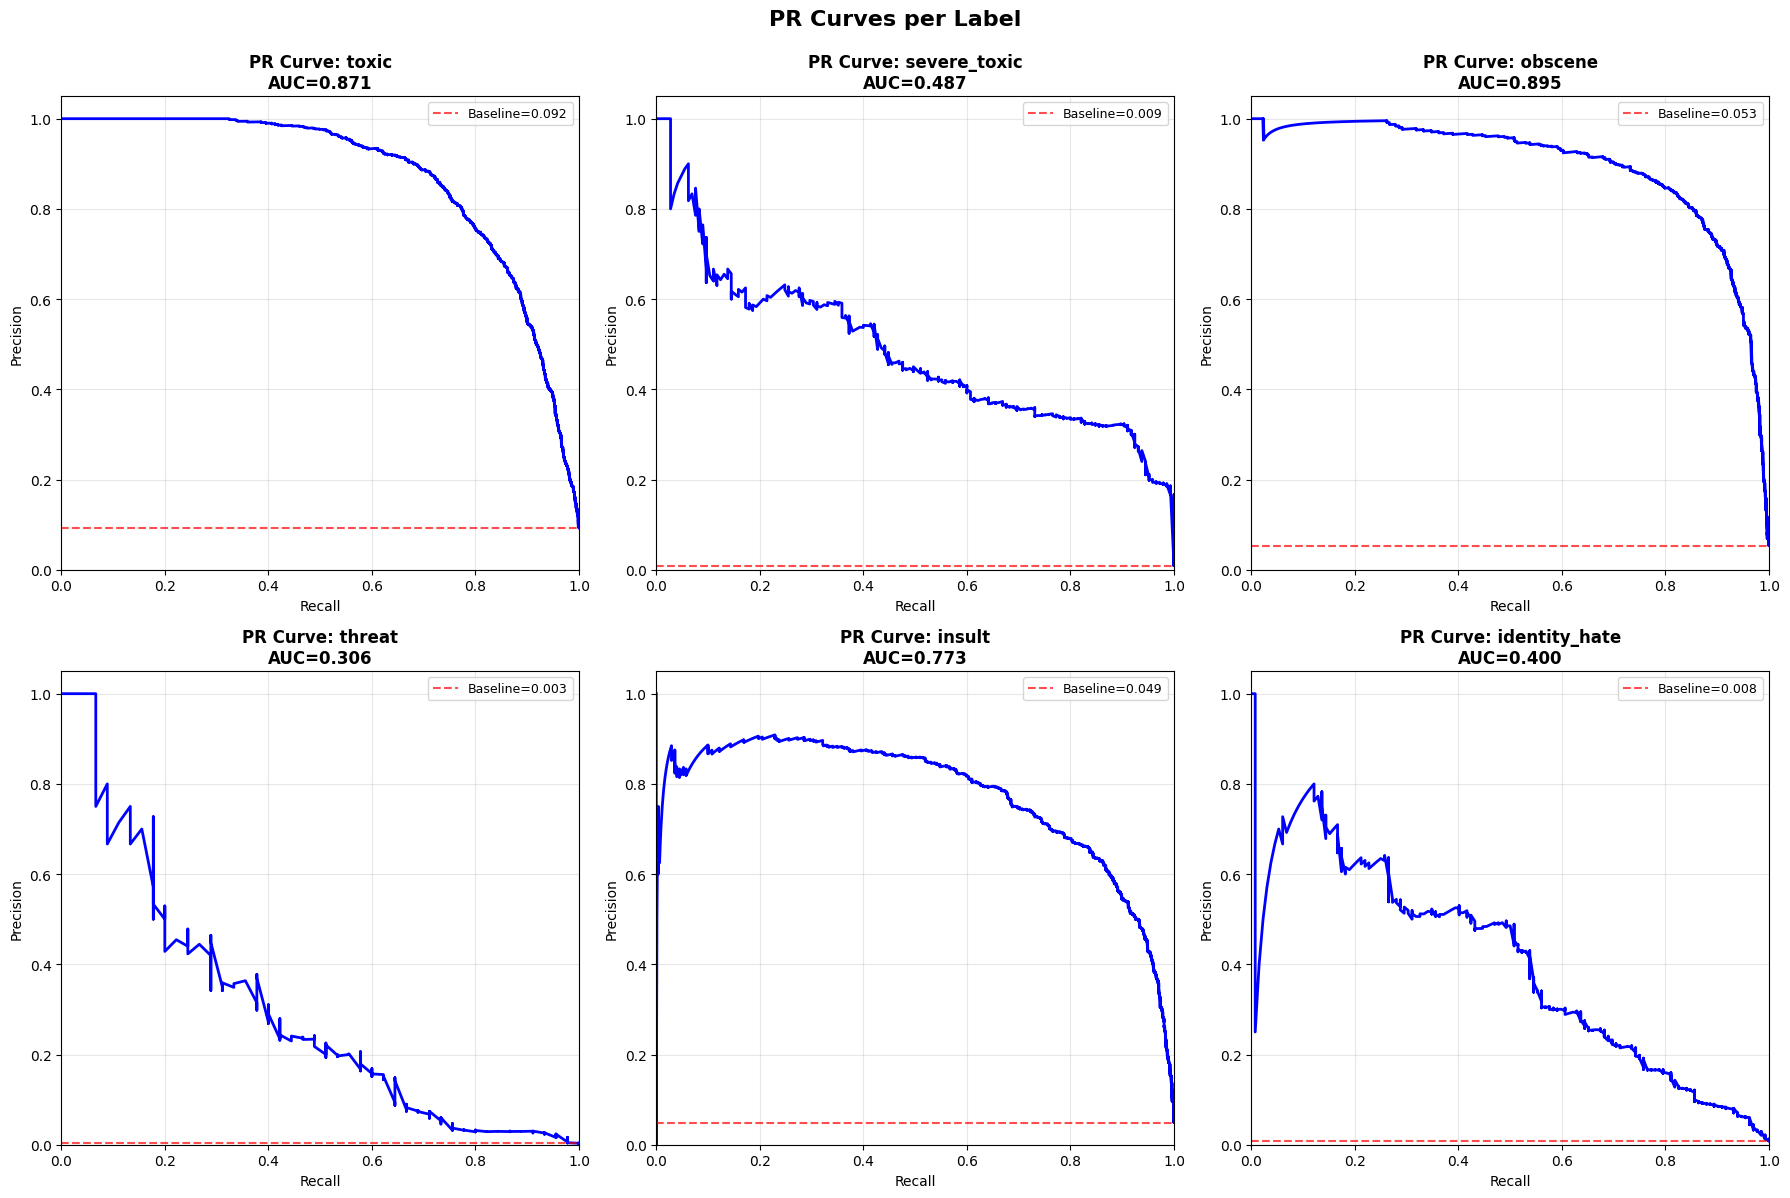

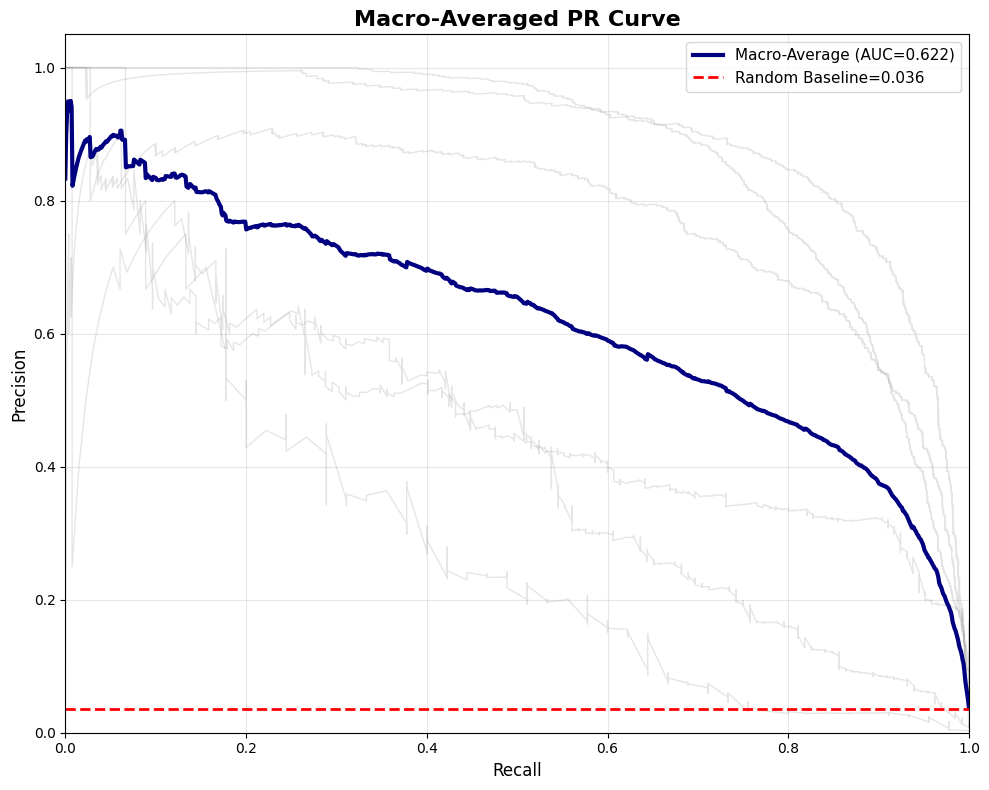


Computing F1 scores across thresholds...


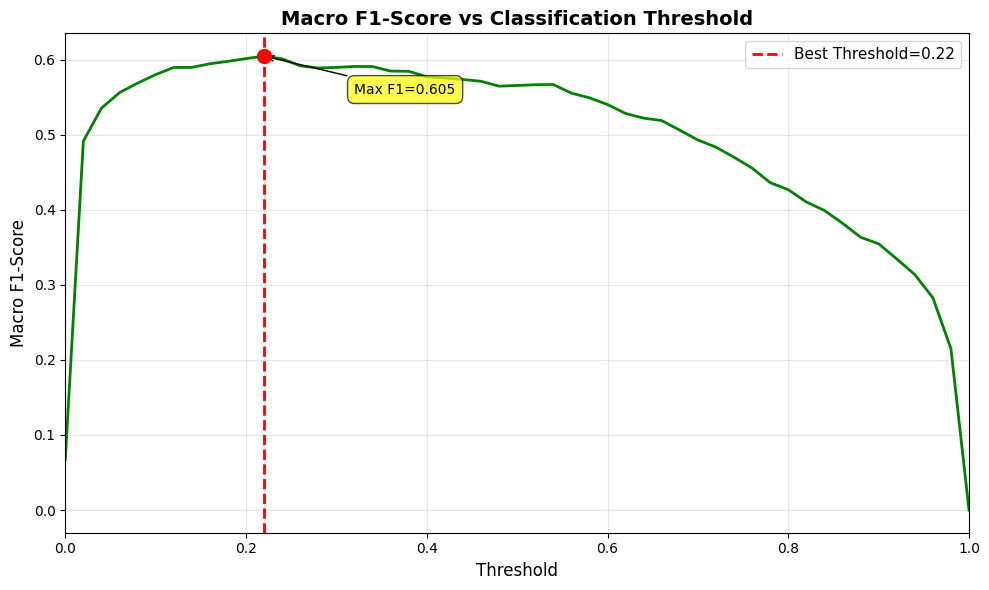

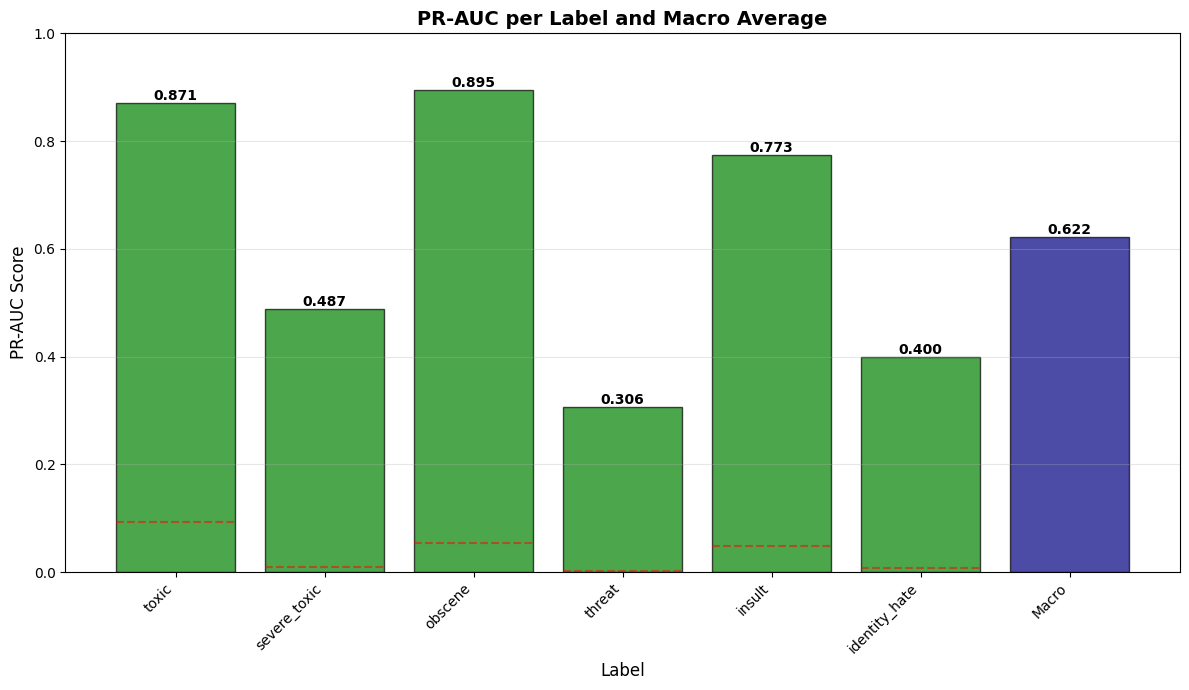


VALIDATION METRICS SUMMARY

Macro-Averaged PR-AUC: 0.6221
Best F1 Threshold:     0.22
Best Macro F1-Score:   0.6051

Per-Label PR-AUC Scores:
----------------------------------------------------------------------
  toxic           | PR-AUC: 0.8710 | Baseline: 0.0924 | Δ: +0.7786
  severe_toxic    | PR-AUC: 0.4874 | Baseline: 0.0091 | Δ: +0.4783
  obscene         | PR-AUC: 0.8949 | Baseline: 0.0533 | Δ: +0.8416
  threat          | PR-AUC: 0.3060 | Baseline: 0.0028 | Δ: +0.3032
  insult          | PR-AUC: 0.7735 | Baseline: 0.0489 | Δ: +0.7246
  identity_hate   | PR-AUC: 0.4001 | Baseline: 0.0083 | Δ: +0.3918

Macro PR-AUC: 0.6221
Use threshold: 0.22 for classification


In [68]:
results = plot_pr_auc_and_f1(model, valid_loader, device)
# Access results
print(f"Macro PR-AUC: {results['macro_pr_auc']:.4f}")
print(f"Use threshold: {results['best_f1_threshold']:.2f} for classification")

In [ ]:

config["start_epoch"] = 10
config["end_epoch"] = 15

with wandb.init(project="nontoxic-world",
                id="h8qg1wsu",
                config=config,
                resume="allow"
               ):
    history = train(
        model, 
        optimizer, 
        xentropy, 
        macro_pr_auc,
        macro_pr_auc,
        train_loader, 
        valid_loader, 
        config,
        checkpoint_path='stacked_bigru_model_5.pth'
    )

Epoch 11/15, train loss: 0.0240, train metric: 76.85%, valid metric: 62.01% [BEST]
Batch 417/499 loss=0.0230